# Parallel Consistency Diagnostic

This notebook tests whether the same ML predictor parameter case produces the same result when run:

1. in a plain Python `for` loop,
2. through `joblib.Parallel(..., n_jobs=1, backend="loky")`, and
3. optionally through `joblib.Parallel(..., n_jobs>1, backend="loky")`.

The point is to isolate the parallelization question from the research notebook state. Run this notebook after restarting the kernel.

## 0. Clean Imports

This cell shuts down reusable `loky` workers and reloads the local modules from disk. This matters because notebook kernels can keep old function objects in memory, while `loky` workers import code separately.

In [ ]:
from pathlib import Path
import os
import sys
import time
import importlib
import itertools

import numpy as np
import pandas as pd
from pandas.testing import assert_frame_equal

from joblib import Parallel, delayed
from joblib.externals.loky import get_reusable_executor

# Make sure this notebook imports from its own folder.
PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name != "ML_predictor":
    PROJECT_DIR = PROJECT_DIR / "research" / "Mateo" / "ML_predictor"

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

# Kill any reusable loky workers that may have imported older code.
get_reusable_executor().shutdown(wait=True)

import ML_predictor
import run_grid_case
import run_single_case

importlib.reload(ML_predictor)
importlib.reload(run_grid_case)
importlib.reload(run_single_case)

from ML_predictor import MLPredictorStrategy
from run_grid_case import run_grid_case
from src.vector_backtester_Mateo import PortfolioVectorEngine

print("Imported from:")
print("ML_predictor:", Path(ML_predictor.__file__).resolve())
print("run_grid_case:", Path(run_grid_case.__code__.co_filename).resolve())
print("cwd:", Path.cwd())

Imported from:
ML_predictor: /Users/mateo/Bluegrey/research/Mateo/ML_predictor/ML_predictor.py
run_grid_case: /Users/mateo/Bluegrey/research/Mateo/ML_predictor/run_grid_case.py
cwd: /Users/mateo/Bluegrey/research/Mateo/ML_predictor


## 1. Define The Cases

These are the same-parameter combinations that overlapped in your notebook. They are intentionally small enough to inspect, but still cover the cases where you saw disagreement.

In [21]:
FIXED = dict(
    symbol="ECH",
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2025-03-01",
    signal_threshold=0.002,
    position_size=1.0,
    initial_capital=1_000_000,
    max_iter=5000,
    execution_delay=1,
    verbose=False,
    show_progress=False,
)

# Set of cases from the inconsistent notebook comparisons.
CASES = []

# Matches the individual loop: n_features varies, training_years fixed at 10.
for nf in [6, 8, 10, 12, 14, 16]:
    CASES.append(dict(n_features=nf, training_years=10))

# Matches the two n_jobs=1 grids: n_features fixed at 12, training_years varies.
for ty in [4, 6, 8, 10, 12, 14]:
    case = dict(n_features=12, training_years=ty)
    if case not in CASES:
        CASES.append(case)

cases_df = pd.DataFrame(CASES)
cases_df

,n_features,training_years
0,6,10
1,8,10
2,10,10
3,12,10
4,14,10
5,16,10
6,12,4
7,12,6
8,12,8
9,12,12


## 2. Comparison Helpers

`run_grid_case` already returns numeric statistics without plotting or creating a tearsheet, so it is the cleanest existing function for this diagnostic. We call the same function in every mode.

In [20]:
RESULT_COLUMNS = [
    "case_id",
    "symbol",
    "start_date",
    "end_date",
    "signal_threshold",
    "n_features",
    "training_years",
    "position_size",
    "max_iter",
    "execution_delay",
    "net_return_pct",
    "gross_return_pct",
    "final_net_equity",
    "final_gross_equity",
]

KEY_COLUMNS = [
    "symbol",
    "start_date",
    "end_date",
    "signal_threshold",
    "n_features",
    "training_years",
    "position_size",
    "max_iter",
    "execution_delay",
]

VALUE_COLUMNS = [
    "net_return_pct",
    "gross_return_pct",
    "final_net_equity",
    "final_gross_equity",
]


def evaluate_case(case_id, case, fixed=FIXED):
    params = {**fixed, **case}
    result = run_grid_case(**params)
    if result is None:
        raise RuntimeError(f"No weights produced for case_id={case_id}, params={params}")
    # run_grid_case currently does not include execution_delay in its returned params.
    result["execution_delay"] = params["execution_delay"]
    result["case_id"] = case_id
    return result


def normalize_results(records):
    df = pd.DataFrame(records)
    missing = [c for c in RESULT_COLUMNS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing expected result columns: {missing}")
    df = df[RESULT_COLUMNS].sort_values("case_id").reset_index(drop=True)
    for col in VALUE_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="raise")
    return df


def run_serial(cases=CASES):
    records = []
    start = time.time()
    for case_id, case in enumerate(cases):
        print(f"serial case {case_id}: {case}")
        records.append(evaluate_case(case_id, case))
    print(f"serial elapsed: {(time.time() - start) / 60:.1f} min")
    return normalize_results(records)


def run_loky(cases=CASES, n_jobs=1):
    get_reusable_executor().shutdown(wait=True)
    start = time.time()
    records = Parallel(n_jobs=n_jobs, backend="loky", verbose=50)(
        delayed(evaluate_case)(case_id, case)
        for case_id, case in enumerate(cases)
    )
    print(f"loky n_jobs={n_jobs} elapsed: {(time.time() - start) / 60:.1f} min")
    return normalize_results(records)


def compare_results(left, right, left_name="left", right_name="right", atol=1e-9, rtol=1e-9):
    left = left.sort_values("case_id").reset_index(drop=True)
    right = right.sort_values("case_id").reset_index(drop=True)

    try:
        assert_frame_equal(
            left[KEY_COLUMNS + VALUE_COLUMNS],
            right[KEY_COLUMNS + VALUE_COLUMNS],
            check_dtype=False,
            atol=atol,
            rtol=rtol,
        )
        print(f"PASS: {left_name} and {right_name} match within atol={atol}, rtol={rtol}.")
        return pd.DataFrame()
    except AssertionError as exc:
        print(f"FAIL: {left_name} and {right_name} differ.")
        print(exc)

    merged = left.merge(
        right,
        on=["case_id"] + KEY_COLUMNS,
        suffixes=(f"_{left_name}", f"_{right_name}"),
        how="outer",
        indicator=True,
    )

    for col in VALUE_COLUMNS:
        merged[f"{col}_diff"] = merged[f"{col}_{right_name}"] - merged[f"{col}_{left_name}"]

    diff_cols = ["case_id"] + KEY_COLUMNS + [
        item
        for col in VALUE_COLUMNS
        for item in (f"{col}_{left_name}", f"{col}_{right_name}", f"{col}_diff")
    ] + ["_merge"]

    diffs = merged[diff_cols]
    display(diffs)
    return diffs

## 3. Test A: Serial Twice

Before testing parallelism, test whether the same serial code is deterministic when called twice. If this fails, the problem is not `Parallel`; the backtest itself is varying between calls.

In [4]:
serial_1 = run_serial(CASES)
serial_1

serial case 0: {'n_features': 6, 'training_years': 10}
serial case 1: {'n_features': 8, 'training_years': 10}
serial case 2: {'n_features': 10, 'training_years': 10}
serial case 3: {'n_features': 12, 'training_years': 10}
serial case 4: {'n_features': 14, 'training_years': 10}
serial case 5: {'n_features': 16, 'training_years': 10}
serial case 6: {'n_features': 12, 'training_years': 4}
serial case 7: {'n_features': 12, 'training_years': 6}
serial case 8: {'n_features': 12, 'training_years': 8}
serial case 9: {'n_features': 12, 'training_years': 12}
serial case 10: {'n_features': 12, 'training_years': 14}
serial elapsed: 7.8 min


,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,-0.188056,0.445735,9.981194e+05,1.004457e+06
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,1.494682,2.135380,1.014947e+06,1.021354e+06
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,1.089126,1.929686,1.010891e+06,1.019297e+06
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,0.528569,1.377982,1.005286e+06,1.013780e+06
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,-2.275379,-1.247685,9.772462e+05,9.875231e+05
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,-0.701445,0.318145,9.929855e+05,1.003181e+06
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,7.233824,7.436529,1.072338e+06,1.074365e+06
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,-1.626411,-1.277761,9.837359e+05,9.872224e+05
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,-1.849653,-1.022457,9.815035e+05,9.897754e+05
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,-0.339494,0.496566,9.966051e+05,1.004966e+06


In [5]:
serial_2 = run_serial(CASES)
serial_2

serial case 0: {'n_features': 6, 'training_years': 10}
serial case 1: {'n_features': 8, 'training_years': 10}
serial case 2: {'n_features': 10, 'training_years': 10}
serial case 3: {'n_features': 12, 'training_years': 10}
serial case 4: {'n_features': 14, 'training_years': 10}
serial case 5: {'n_features': 16, 'training_years': 10}
serial case 6: {'n_features': 12, 'training_years': 4}
serial case 7: {'n_features': 12, 'training_years': 6}
serial case 8: {'n_features': 12, 'training_years': 8}
serial case 9: {'n_features': 12, 'training_years': 12}
serial case 10: {'n_features': 12, 'training_years': 14}
serial elapsed: 8.0 min


,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,-0.188056,0.445735,9.981194e+05,1.004457e+06
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,1.494682,2.135380,1.014947e+06,1.021354e+06
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,1.089126,1.929686,1.010891e+06,1.019297e+06
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,0.528569,1.377982,1.005286e+06,1.013780e+06
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,-2.275379,-1.247685,9.772462e+05,9.875231e+05
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,-0.701445,0.318145,9.929855e+05,1.003181e+06
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,7.233824,7.436529,1.072338e+06,1.074365e+06
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,-1.626411,-1.277761,9.837359e+05,9.872224e+05
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,-1.849653,-1.022457,9.815035e+05,9.897754e+05
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,-0.339494,0.496566,9.966051e+05,1.004966e+06


In [6]:
serial_vs_serial_diffs = compare_results(serial_1, serial_2, "serial_1", "serial_2")

PASS: serial_1 and serial_2 match within atol=1e-09, rtol=1e-09.


## 4. Test B: Serial vs `loky`, `n_jobs=1`

This is the direct test of the suspicious case. `n_jobs=1` should match the serial loop. If it does not, then either imports/state/data differ between the main process and the worker process, or the function is not pure.

In [7]:
loky_1 = run_loky(CASES, n_jobs=1)
loky_1

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   29.2s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:   57.0s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:  1.6min
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:  2.7min
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:  3.8min
[Parallel(n_jobs=1)]: Done   6 tasks      | elapsed:  4.7min
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:  5.0min
[Parallel(n_jobs=1)]: Done   8 tasks      | elapsed:  5.8min
[Parallel(n_jobs=1)]: Done   9 tasks      | elapsed:  6.3min
[Parallel(n_jobs=1)]: Done  10 tasks      | elapsed:  6.8min
[Parallel(n_jobs=1)]: Done  11 tasks      | elapsed:  7.4min
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:  7.4min finished
loky n_jobs=1 elapsed: 7.4 min


,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,-0.188056,0.445735,9.981194e+05,1.004457e+06
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,1.494682,2.135380,1.014947e+06,1.021354e+06
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,1.089126,1.929686,1.010891e+06,1.019297e+06
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,0.528569,1.377982,1.005286e+06,1.013780e+06
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,-2.275379,-1.247685,9.772462e+05,9.875231e+05
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,-0.701445,0.318145,9.929855e+05,1.003181e+06
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,7.233824,7.436529,1.072338e+06,1.074365e+06
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,-1.626411,-1.277761,9.837359e+05,9.872224e+05
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,-1.849653,-1.022457,9.815035e+05,9.897754e+05
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,-0.339494,0.496566,9.966051e+05,1.004966e+06


In [8]:
serial_vs_loky1_diffs = compare_results(serial_1, loky_1, "serial", "loky1")

PASS: serial and loky1 match within atol=1e-09, rtol=1e-09.


## 5. Test C: Serial vs Multi-worker `loky`

Only run this after Test A and Test B pass. If `n_jobs=1` passes but `n_jobs>1` fails, the issue is specifically related to concurrent execution, memory pressure, nested multiprocessing, or shared external resources.

In [9]:
# Adjust to your machine. Start with 2 before trying 4 or -1.
loky_2 = run_loky(CASES, n_jobs=2)
loky_2

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   27.8s
[Parallel(n_jobs=2)]: Done   2 tasks      | elapsed:   29.1s
[Parallel(n_jobs=2)]: Done   3 tasks      | elapsed:   58.4s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:  1.5min
[Parallel(n_jobs=2)]: Done   5 tasks      | elapsed:  2.1min
[Parallel(n_jobs=2)]: Done   6 tasks      | elapsed:  2.4min
[Parallel(n_jobs=2)]: Done   7 tasks      | elapsed:  2.7min
[Parallel(n_jobs=2)]: Done   8 tasks      | elapsed:  3.0min
[Parallel(n_jobs=2)]: Done   9 out of  11 | elapsed:  3.3min remaining:   43.4s
[Parallel(n_jobs=2)]: Done  11 out of  11 | elapsed:  4.3min finished
loky n_jobs=2 elapsed: 4.3 min


,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,-0.188083,0.445709,9.981192e+05,1.004457e+06
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,1.494703,2.135400,1.014947e+06,1.021354e+06
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,1.089102,1.929662,1.010891e+06,1.019297e+06
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,1.343307,2.292204,1.013433e+06,1.022922e+06
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,-2.275401,-1.247708,9.772460e+05,9.875229e+05
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,-1.318327,-0.400856,9.868167e+05,9.959914e+05
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,7.342665,7.436503,1.073427e+06,1.074365e+06
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,-1.626404,-1.277753,9.837360e+05,9.872225e+05
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,-1.849673,-1.022476,9.815033e+05,9.897752e+05
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,-2.105294,-1.179703,9.789471e+05,9.882030e+05


In [10]:
serial_vs_loky2_diffs = compare_results(serial_1, loky_2, "serial", "loky2")

FAIL: serial and loky2 differ.
DataFrame.iloc[:, 9] (column name="net_return_pct") are different

DataFrame.iloc[:, 9] (column name="net_return_pct") values are different (100.0 %)
[index]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[left]:  [-0.18805622986678427, 1.494682207247644, 1.0891262742134478, 0.5285687246059378, -2.2753792778450577, -0.701445057300143, 7.233824482924445, -1.6264112079507953, -1.8496534733956405, -0.3394943311958776, -0.5178662531040823]
[right]: [-0.18808292593840426, 1.494702599339881, 1.0891023980757808, 1.3433067029652301, -2.275401378267805, -1.3183273789860617, 7.342664532176335, -1.626403677391075, -1.849672822798365, -2.1052937445288245, -4.818543413528575]
At positional index 0, first diff: -0.18805622986678427 != -0.18808292593840426


,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,...,gross_return_pct_serial,gross_return_pct_loky2,gross_return_pct_diff,final_net_equity_serial,final_net_equity_loky2,final_net_equity_diff,final_gross_equity_serial,final_gross_equity_loky2,final_gross_equity_diff,_merge
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,...,0.445735,0.445709,-0.000027,9.981194e+05,9.981192e+05,-0.266961,1.004457e+06,1.004457e+06,-0.266942,both
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,...,2.135380,2.135400,0.000020,1.014947e+06,1.014947e+06,0.203921,1.021354e+06,1.021354e+06,0.203796,both
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,...,1.929686,1.929662,-0.000024,1.010891e+06,1.010891e+06,-0.238761,1.019297e+06,1.019297e+06,-0.239583,both
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,...,1.377982,2.292204,0.914222,1.005286e+06,1.013433e+06,8147.379784,1.013780e+06,1.022922e+06,9142.217682,both
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,...,-1.247685,-1.247708,-0.000022,9.772462e+05,9.772460e+05,-0.221004,9.875231e+05,9.875229e+05,-0.222042,both
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,...,0.318145,-0.400856,-0.719001,9.929855e+05,9.868167e+05,-6168.823217,1.003181e+06,9.959914e+05,-7190.009578,both
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,...,7.436529,7.436503,-0.000026,1.072338e+06,1.073427e+06,1088.400493,1.074365e+06,1.074365e+06,-0.258325,both
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,...,-1.277761,-1.277753,0.000008,9.837359e+05,9.837360e+05,0.075306,9.872224e+05,9.872225e+05,0.075612,both
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,...,-1.022457,-1.022476,-0.000019,9.815035e+05,9.815033e+05,-0.193494,9.897754e+05,9.897752e+05,-0.193826,both
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,...,0.496566,-1.179703,-1.676270,9.966051e+05,9.789471e+05,-17657.994133,1.004966e+06,9.882030e+05,-16762.695762,both


## 6. Strict Frozen-input Test

The previous tests use the current `run_grid_case`, which downloads data inside each case. This section freezes the raw Yahoo OHLCV data once, then gives every case the same raw input.

This is the cleaner design for parallel research: workers should not independently download external data.

In [23]:
def download_frozen_raw(fixed=FIXED, cases=CASES):
    max_training_years = max(case["training_years"] for case in cases)
    params = {
        "symbol": fixed["symbol"],
        "start_date": fixed["start_date"],
        "end_date": fixed["end_date"],
        "training_years": max_training_years,
        "signal_threshold": fixed["signal_threshold"],
        "n_features": fixed.get("n_features", 6),
        "max_iter": fixed["max_iter"],
        "verbose": fixed["verbose"],
    }
    strategy = MLPredictorStrategy(params=params)
    raw = strategy.download_dataset(training_years=max_training_years)
    return raw.copy(deep=True)


def prepare_dataset_from_raw(raw_ohlcv, params):
    strategy = MLPredictorStrategy(params=params)
    df = raw_ohlcv.copy(deep=True)
    df = strategy.assign_signal(df)
    df = strategy.compute_technical_indicators(df).copy()
    df = strategy.clean_dataset(df)
    return strategy, df


def evaluate_case_frozen(case_id, case, raw_ohlcv, fixed=FIXED):
    params = {**fixed, **case}
    strategy, dataset = prepare_dataset_from_raw(raw_ohlcv, params)
    weights = strategy.generate_signals(dataset, show_progress=params["show_progress"])
    if weights.empty:
        raise RuntimeError(f"No weights produced for case_id={case_id}, params={params}")

    prices = dataset[["Open"]].rename(columns={"Open": params["symbol"]}).loc[weights.index]
    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=params["asset_class"],
        initial_capital=params["initial_capital"],
        execution_delay=params["execution_delay"],
    )
    stats = engine.run()

    return {
        "case_id": case_id,
        "symbol": params["symbol"],
        "start_date": params["start_date"],
        "end_date": params["end_date"],
        "signal_threshold": params["signal_threshold"],
        "n_features": params["n_features"],
        "training_years": params["training_years"],
        "position_size": params["position_size"],
        "max_iter": params["max_iter"],
        "execution_delay": params["execution_delay"],
        "net_return_pct": (stats["net_equity"].iloc[-1] / params["initial_capital"] - 1) * 100,
        "gross_return_pct": (stats["gross_equity"].iloc[-1] / params["initial_capital"] - 1) * 100,
        "final_net_equity": stats["net_equity"].iloc[-1],
        "final_gross_equity": stats["gross_equity"].iloc[-1],
    }


def run_serial_frozen(raw_ohlcv, cases=CASES):
    records = []
    start = time.time()
    for case_id, case in enumerate(cases):
        print(f"serial frozen case {case_id}: {case}")
        records.append(evaluate_case_frozen(case_id, case, raw_ohlcv))
    print(f"serial frozen elapsed: {(time.time() - start) / 60:.1f} min")
    return normalize_results(records)


def run_loky_frozen(raw_ohlcv, cases=CASES, n_jobs=1):
    get_reusable_executor().shutdown(wait=True)
    start = time.time()
    records = Parallel(n_jobs=n_jobs, backend="loky", verbose=50)(
        delayed(evaluate_case_frozen)(case_id, case, raw_ohlcv)
        for case_id, case in enumerate(cases)
    )
    print(f"loky frozen n_jobs={n_jobs} elapsed: {(time.time() - start) / 60:.1f} min")
    return normalize_results(records)

In [24]:
raw_ohlcv = download_frozen_raw(FIXED, CASES)
raw_ohlcv.head(), raw_ohlcv.tail(), raw_ohlcv.shape

(ECH              Open       High        Low      Close  Volume
 Date                                                          
 2010-01-04  36.720272  37.202651  36.356837  37.070492   91800
 2010-01-05  37.242304  37.367854  37.070496  37.222481  122300
 2010-01-06  37.513229  37.883274  37.427326  37.823803  118500
 2010-01-07  37.810588  38.709267  37.764332  38.709267  653300
 2010-01-08  38.788560  39.284155  38.610146  39.237900  336000,
 ECH              Open       High        Low      Close  Volume
 Date                                                          
 2025-02-24  27.607131  27.779976  27.415080  27.731962  175400
 2025-02-25  27.914408  27.914408  27.626334  27.779974  121000
 2025-02-26  27.808783  27.914411  27.655143  27.741566  140300
 2025-02-27  27.683951  27.770373  27.424684  27.597528  204700
 2025-02-28  27.568722  27.722364  27.242240  27.482302  240400,
 (3813, 5))

In [13]:
frozen_serial = run_serial_frozen(raw_ohlcv, CASES)
frozen_serial

serial frozen case 0: {'n_features': 6, 'training_years': 10}
serial frozen case 1: {'n_features': 8, 'training_years': 10}
serial frozen case 2: {'n_features': 10, 'training_years': 10}
serial frozen case 3: {'n_features': 12, 'training_years': 10}
serial frozen case 4: {'n_features': 14, 'training_years': 10}
serial frozen case 5: {'n_features': 16, 'training_years': 10}
serial frozen case 6: {'n_features': 12, 'training_years': 4}
serial frozen case 7: {'n_features': 12, 'training_years': 6}
serial frozen case 8: {'n_features': 12, 'training_years': 8}
serial frozen case 9: {'n_features': 12, 'training_years': 12}
serial frozen case 10: {'n_features': 12, 'training_years': 14}
serial frozen elapsed: 9.3 min


,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,-0.188071,0.445721,9.981193e+05,1.004457e+06
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,1.494653,2.135350,1.014947e+06,1.021354e+06
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,1.089098,1.929658,1.010891e+06,1.019297e+06
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,1.343320,2.292217,1.013433e+06,1.022922e+06
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,-4.541248,-3.421841,9.545875e+05,9.657816e+05
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,-1.318312,-0.400841,9.868169e+05,9.959916e+05
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,7.342665,7.436503,1.073427e+06,1.074365e+06
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,-1.626396,-1.277746,9.837360e+05,9.872225e+05
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,-1.798383,-1.022446,9.820162e+05,9.897755e+05
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,-0.339522,0.496538,9.966048e+05,1.004965e+06


In [14]:
frozen_loky1 = run_loky_frozen(raw_ohlcv, CASES, n_jobs=1)
frozen_loky1

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   39.3s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:  1.1min
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:  1.8min
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:  3.2min
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:  4.8min
[Parallel(n_jobs=1)]: Done   6 tasks      | elapsed:  6.3min
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:  6.7min
[Parallel(n_jobs=1)]: Done   8 tasks      | elapsed:  7.9min
[Parallel(n_jobs=1)]: Done   9 tasks      | elapsed:  8.5min
[Parallel(n_jobs=1)]: Done  10 tasks      | elapsed:  9.1min
[Parallel(n_jobs=1)]: Done  11 tasks      | elapsed:  9.9min
[Parallel(n_jobs=1)]: Done  11 out of  11 | elapsed:  9.9min finished
loky frozen n_jobs=1 elapsed: 9.9 min


,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,-0.188071,0.445721,9.981193e+05,1.004457e+06
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,1.494653,2.135350,1.014947e+06,1.021354e+06
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,1.089098,1.929658,1.010891e+06,1.019297e+06
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,1.343320,2.292217,1.013433e+06,1.022922e+06
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,-4.541248,-3.421841,9.545875e+05,9.657816e+05
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,-1.318312,-0.400841,9.868169e+05,9.959916e+05
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,7.342665,7.436503,1.073427e+06,1.074365e+06
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,-1.626396,-1.277746,9.837360e+05,9.872225e+05
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,-1.798383,-1.022446,9.820162e+05,9.897755e+05
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,-0.339522,0.496538,9.966048e+05,1.004965e+06


In [15]:
frozen_serial_vs_loky1_diffs = compare_results(frozen_serial, frozen_loky1, "frozen_serial", "frozen_loky1")

PASS: frozen_serial and frozen_loky1 match within atol=1e-09, rtol=1e-09.


In [16]:
# Optional after the previous frozen test passes.
frozen_loky2 = run_loky_frozen(raw_ohlcv, CASES, n_jobs=2)
frozen_serial_vs_loky2_diffs = compare_results(frozen_serial, frozen_loky2, "frozen_serial", "frozen_loky2")

[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   45.7s
[Parallel(n_jobs=2)]: Done   2 tasks      | elapsed:   53.8s
[Parallel(n_jobs=2)]: Done   3 tasks      | elapsed:  1.5min
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:  2.5min
[Parallel(n_jobs=2)]: Done   5 tasks      | elapsed:  3.0min
[Parallel(n_jobs=2)]: Done   6 tasks      | elapsed:  3.5min
[Parallel(n_jobs=2)]: Done   7 tasks      | elapsed:  4.7min
[Parallel(n_jobs=2)]: Done   8 tasks      | elapsed:  4.9min
[Parallel(n_jobs=2)]: Done   9 out of  11 | elapsed:  5.6min remaining:  1.2min
[Parallel(n_jobs=2)]: Done  11 out of  11 | elapsed:  6.5min finished
loky frozen n_jobs=2 elapsed: 6.5 min
PASS: frozen_serial and frozen_loky2 match within atol=1e-09, rtol=1e-09.


In [19]:
frozen_loky2

,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,-0.188071,0.445721,9.981193e+05,1.004457e+06
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,1.494653,2.135350,1.014947e+06,1.021354e+06
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,1.089098,1.929658,1.010891e+06,1.019297e+06
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,1.343320,2.292217,1.013433e+06,1.022922e+06
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,-4.541248,-3.421841,9.545875e+05,9.657816e+05
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,-1.318312,-0.400841,9.868169e+05,9.959916e+05
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,7.342665,7.436503,1.073427e+06,1.074365e+06
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,-1.626396,-1.277746,9.837360e+05,9.872225e+05
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,-1.798383,-1.022446,9.820162e+05,9.897755e+05
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,-0.339522,0.496538,9.966048e+05,1.004965e+06


In [17]:
# Optional after the previous frozen test passes.
frozen_loky4 = run_loky_frozen(raw_ohlcv, CASES, n_jobs=4)
frozen_serial_vs_loky4_diffs = compare_results(frozen_serial, frozen_loky4, "frozen_serial", "frozen_loky4")

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:  1.0min
[Parallel(n_jobs=4)]: Done   2 tasks      | elapsed:  1.2min
[Parallel(n_jobs=4)]: Done   3 tasks      | elapsed:  1.4min
[Parallel(n_jobs=4)]: Done   4 tasks      | elapsed:  2.1min
[Parallel(n_jobs=4)]: Done   5 out of  11 | elapsed:  2.5min remaining:  3.0min
[Parallel(n_jobs=4)]: Done   6 out of  11 | elapsed:  3.5min remaining:  2.9min
[Parallel(n_jobs=4)]: Done   7 out of  11 | elapsed:  3.5min remaining:  2.0min
[Parallel(n_jobs=4)]: Done   8 out of  11 | elapsed:  3.8min remaining:  1.4min
[Parallel(n_jobs=4)]: Done   9 out of  11 | elapsed:  4.1min remaining:   54.0s
[Parallel(n_jobs=4)]: Done  11 out of  11 | elapsed:  4.7min finished
loky frozen n_jobs=4 elapsed: 4.7 min
PASS: frozen_serial and frozen_loky4 match within atol=1e-09, rtol=1e-09.


In [20]:
frozen_loky4

,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,-0.188071,0.445721,9.981193e+05,1.004457e+06
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,1.494653,2.135350,1.014947e+06,1.021354e+06
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,1.089098,1.929658,1.010891e+06,1.019297e+06
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,1.343320,2.292217,1.013433e+06,1.022922e+06
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,-4.541248,-3.421841,9.545875e+05,9.657816e+05
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,-1.318312,-0.400841,9.868169e+05,9.959916e+05
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,7.342665,7.436503,1.073427e+06,1.074365e+06
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,-1.626396,-1.277746,9.837360e+05,9.872225e+05
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,-1.798383,-1.022446,9.820162e+05,9.897755e+05
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,-0.339522,0.496538,9.966048e+05,1.004965e+06


In [18]:
# Optional after the previous frozen test passes.
frozen_lokyN1 = run_loky_frozen(raw_ohlcv, CASES, n_jobs=-1)
frozen_serial_vs_lokyN1_diffs = compare_results(frozen_serial, frozen_lokyN1, "frozen_serial", "frozen_lokyN1")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.5min
[Parallel(n_jobs=-1)]: Done   2 out of  11 | elapsed:  1.8min remaining:  8.2min
[Parallel(n_jobs=-1)]: Done   3 out of  11 | elapsed:  2.1min remaining:  5.6min
[Parallel(n_jobs=-1)]: Done   4 out of  11 | elapsed:  2.6min remaining:  4.6min
[Parallel(n_jobs=-1)]: Done   5 out of  11 | elapsed:  3.4min remaining:  4.1min
[Parallel(n_jobs=-1)]: Done   6 out of  11 | elapsed:  3.8min remaining:  3.1min
[Parallel(n_jobs=-1)]: Done   7 out of  11 | elapsed:  3.8min remaining:  2.2min
[Parallel(n_jobs=-1)]: Done   8 out of  11 | elapsed:  4.2min remaining:  1.6min
[Parallel(n_jobs=-1)]: Done   9 out of  11 | elapsed:  4.3min remaining:   57.1s
[Parallel(n_jobs=-1)]: Done  11 out of  11 | elapsed:  4.4min finished
loky frozen n_jobs=-1 elapsed: 4.4 min
PASS: frozen_serial and frozen_lokyN1 match within atol=1e-09, rtol=1e-09.


In [21]:
frozen_lokyN1

,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,-0.188071,0.445721,9.981193e+05,1.004457e+06
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,1.494653,2.135350,1.014947e+06,1.021354e+06
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,1.089098,1.929658,1.010891e+06,1.019297e+06
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,1.343320,2.292217,1.013433e+06,1.022922e+06
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,-4.541248,-3.421841,9.545875e+05,9.657816e+05
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,-1.318312,-0.400841,9.868169e+05,9.959916e+05
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,7.342665,7.436503,1.073427e+06,1.074365e+06
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,-1.626396,-1.277746,9.837360e+05,9.872225e+05
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,-1.798383,-1.022446,9.820162e+05,9.897755e+05
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,-0.339522,0.496538,9.966048e+05,1.004965e+06


## 7. Test D: Fresh-input vs Frozen-input



In [22]:
serial_vs_frozen_serial_diffs = compare_results(serial_1, frozen_serial, "serial", "frozen_serial") 

FAIL: serial and frozen_serial differ.
DataFrame.iloc[:, 9] (column name="net_return_pct") are different

DataFrame.iloc[:, 9] (column name="net_return_pct") values are different (90.90909 %)
[index]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[left]:  [-0.18805622986678427, 1.494682207247644, 1.0891262742134478, 0.5285687246059378, -2.2753792778450577, -0.701445057300143, 7.233824482924445, -1.6264112079507953, -1.8496534733956405, -0.3394943311958776, -0.5178662531040823]
[right]: [-0.1880711322206019, 1.4946527883382243, 1.0890978867788004, 1.3433198350961462, -4.54124784564468, -1.3183119344442384, 7.342664532176335, -1.6263960882762718, -1.798383227717959, -0.3395223166936856, -0.5178662531040823]
At positional index 0, first diff: -0.18805622986678427 != -0.1880711322206019


,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,...,gross_return_pct_serial,gross_return_pct_frozen_serial,gross_return_pct_diff,final_net_equity_serial,final_net_equity_frozen_serial,final_net_equity_diff,final_gross_equity_serial,final_gross_equity_frozen_serial,final_gross_equity_diff,_merge
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,...,0.445735,0.445721,-0.000015,9.981194e+05,9.981193e+05,-0.149024,1.004457e+06,1.004457e+06,-0.149370,both
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,...,2.135380,2.135350,-0.000030,1.014947e+06,1.014947e+06,-0.294189,1.021354e+06,1.021354e+06,-0.295063,both
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,...,1.929686,1.929658,-0.000028,1.010891e+06,1.010891e+06,-0.283874,1.019297e+06,1.019297e+06,-0.284128,both
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,...,1.377982,2.292217,0.914235,1.005286e+06,1.013433e+06,8147.511105,1.013780e+06,1.022922e+06,9142.349892,both
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,...,-1.247685,-3.421841,-2.174155,9.772462e+05,9.545875e+05,-22658.685678,9.875231e+05,9.657816e+05,-21741.550222,both
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,...,0.318145,-0.400841,-0.718985,9.929855e+05,9.868169e+05,-6168.668771,1.003181e+06,9.959916e+05,-7189.853734,both
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,...,7.436529,7.436503,-0.000026,1.072338e+06,1.073427e+06,1088.400493,1.074365e+06,1.074365e+06,-0.258325,both
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,...,-1.277761,-1.277746,0.000015,9.837359e+05,9.837360e+05,0.151197,9.872224e+05,9.872225e+05,0.151775,both
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,...,-1.022457,-1.022446,0.000010,9.815035e+05,9.820162e+05,512.702457,9.897754e+05,9.897755e+05,0.102783,both
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,...,0.496566,0.496538,-0.000028,9.966051e+05,9.966048e+05,-0.279855,1.004966e+06,1.004965e+06,-0.279844,both


In [25]:
loky2_vs_frozen_serial_diffs = compare_results(loky_2, frozen_serial, "loky_2", "frozen_serial")

FAIL: loky_2 and frozen_serial differ.
DataFrame.iloc[:, 9] (column name="net_return_pct") are different

DataFrame.iloc[:, 9] (column name="net_return_pct") values are different (90.90909 %)
[index]: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
[left]:  [-0.18808292593840426, 1.494702599339881, 1.0891023980757808, 1.3433067029652301, -2.275401378267805, -1.3183273789860617, 7.342664532176335, -1.626403677391075, -1.849672822798365, -2.1052937445288245, -4.818543413528575]
[right]: [-0.1880711322206019, 1.4946527883382243, 1.0890978867788004, 1.3433198350961462, -4.54124784564468, -1.3183119344442384, 7.342664532176335, -1.6263960882762718, -1.798383227717959, -0.3395223166936856, -0.5178662531040823]
At positional index 0, first diff: -0.18808292593840426 != -0.1880711322206019


,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,...,gross_return_pct_loky_2,gross_return_pct_frozen_serial,gross_return_pct_diff,final_net_equity_loky_2,final_net_equity_frozen_serial,final_net_equity_diff,final_gross_equity_loky_2,final_gross_equity_frozen_serial,final_gross_equity_diff,_merge
0,0,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,...,0.445709,0.445721,0.000012,9.981192e+05,9.981193e+05,0.117937,1.004457e+06,1.004457e+06,0.117572,both
1,1,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,...,2.135400,2.135350,-0.000050,1.014947e+06,1.014947e+06,-0.498110,1.021354e+06,1.021354e+06,-0.498859,both
2,2,ECH,2025-01-01,2025-03-01,0.002,10,10,1.0,5000,1,...,1.929662,1.929658,-0.000004,1.010891e+06,1.010891e+06,-0.045113,1.019297e+06,1.019297e+06,-0.044545,both
3,3,ECH,2025-01-01,2025-03-01,0.002,12,10,1.0,5000,1,...,2.292204,2.292217,0.000013,1.013433e+06,1.013433e+06,0.131321,1.022922e+06,1.022922e+06,0.132210,both
4,4,ECH,2025-01-01,2025-03-01,0.002,14,10,1.0,5000,1,...,-1.247708,-3.421841,-2.174133,9.772460e+05,9.545875e+05,-22658.464674,9.875229e+05,9.657816e+05,-21741.328180,both
5,5,ECH,2025-01-01,2025-03-01,0.002,16,10,1.0,5000,1,...,-0.400856,-0.400841,0.000016,9.868167e+05,9.868169e+05,0.154445,9.959914e+05,9.959916e+05,0.155844,both
6,6,ECH,2025-01-01,2025-03-01,0.002,12,4,1.0,5000,1,...,7.436503,7.436503,0.000000,1.073427e+06,1.073427e+06,0.000000,1.074365e+06,1.074365e+06,0.000000,both
7,7,ECH,2025-01-01,2025-03-01,0.002,12,6,1.0,5000,1,...,-1.277753,-1.277746,0.000008,9.837360e+05,9.837360e+05,0.075891,9.872225e+05,9.872225e+05,0.076163,both
8,8,ECH,2025-01-01,2025-03-01,0.002,12,8,1.0,5000,1,...,-1.022476,-1.022446,0.000030,9.815033e+05,9.820162e+05,512.895951,9.897752e+05,9.897755e+05,0.296608,both
9,9,ECH,2025-01-01,2025-03-01,0.002,12,12,1.0,5000,1,...,-1.179703,0.496538,1.676242,9.789471e+05,9.966048e+05,17657.714278,9.882030e+05,1.004965e+06,16762.415918,both


All the other comparisons can be deduced from the obtained comparisons.

## 8. Test with `parameter_grid_search`

In this section I want to test if `parameter_grid_search` will work well (and pass the same tests as just `Parallel(loky)` did) when using frozen-input data.

### Frozen-input `parameter_grid_search` helpers

These helpers call the real `parameter_grid_search`, but temporarily replace the module-level `run_grid_case` it uses with a frozen-input version. This tests the grid-search orchestration while removing repeated Yahoo downloads from each case.

In [25]:
from IPython.display import display as ipy_display


def run_grid_case_frozen_from_raw(
    raw_ohlcv,
    symbol,
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2025-03-01",
    signal_threshold=0.002,
    n_features=6,
    training_years=10,
    position_size=1.0,
    initial_capital=1_000_000,
    max_iter=5000,
    execution_delay=1,
    verbose=False,
    show_progress=False,
):
    params = {
        "symbol": symbol,
        "start_date": start_date,
        "end_date": end_date,
        "signal_threshold": signal_threshold,
        "n_features": n_features,
        "training_years": training_years,
        "position_size": position_size,
        "max_iter": max_iter,
        "verbose": verbose,
        "show_progress": show_progress,
    }

    strategy, dataset = prepare_dataset_from_raw(raw_ohlcv, params)
    weights = strategy.generate_signals(dataset, show_progress=show_progress)
    if weights.empty:
        return None

    prices = dataset[["Open"]].rename(columns={"Open": symbol}).loc[weights.index]
    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=asset_class,
        initial_capital=initial_capital,
        execution_delay=execution_delay,
    )
    stats = engine.run()

    return {
        **params,
        "execution_delay": execution_delay,
        "net_return_pct": (stats["net_equity"].iloc[-1] / initial_capital - 1) * 100,
        "gross_return_pct": (stats["gross_equity"].iloc[-1] / initial_capital - 1) * 100,
        "final_net_equity": stats["net_equity"].iloc[-1],
        "final_gross_equity": stats["gross_equity"].iloc[-1],
    }


def cases_from_grid(var_1, list_1, var_2, list_2):
    cases = [{var_1: value_1, var_2: value_2} for value_1 in list_1 for value_2 in list_2]
    return sorted(cases, key=lambda case: (case[var_1], case[var_2]))


def normalize_parameter_grid_df(grid_df, var_1, var_2):
    df = grid_df.sort_values([var_1, var_2]).reset_index(drop=True).copy()
    if "execution_delay" not in df.columns:
        df["execution_delay"] = FIXED["execution_delay"]
    df["case_id"] = range(len(df))
    return normalize_results(df.to_dict("records"))


def run_parameter_grid_search_frozen(
    raw_ohlcv,
    *,
    symbol,
    var_1,
    list_1,
    var_2,
    list_2,
    n_jobs=1,
    verbose=50,
    **extra_kwargs,
):
    run_grid_case_module = sys.modules["run_grid_case"]

    captured_displays = []
    original_run_grid_case = run_grid_case_module.run_grid_case
    original_display = run_grid_case_module.display
    original_show = run_grid_case_module.plt.show

    def frozen_adapter(**kwargs):
        return run_grid_case_frozen_from_raw(raw_ohlcv, **kwargs)

    def capture_display(obj):
        if isinstance(obj, pd.DataFrame):
            captured_displays.append(obj.copy())
        ipy_display(obj)

    try:
        run_grid_case_module.run_grid_case = frozen_adapter
        run_grid_case_module.display = capture_display
        run_grid_case_module.plt.show = lambda *args, **kwargs: None

        run_grid_case_module.parameter_grid_search(
            symbol=symbol,
            var_1=var_1,
            list_1=list_1,
            var_2=var_2,
            list_2=list_2,
            n_jobs=n_jobs,
            verbose=verbose,
            **extra_kwargs,
        )
    finally:
        run_grid_case_module.run_grid_case = original_run_grid_case
        run_grid_case_module.display = original_display
        run_grid_case_module.plt.show = original_show
        get_reusable_executor().shutdown(wait=True)

    if not captured_displays:
        raise RuntimeError("parameter_grid_search did not display a DataFrame to capture.")

    return normalize_parameter_grid_df(captured_displays[0], var_1, var_2)

### Grid 1: `n_features` vs `training_years`

This mirrors the grid where the stale notebook output disagreed with the individual runs. The direct frozen evaluator and frozen `parameter_grid_search` should match.

In [26]:
GRID_1 = dict(
    var_1="n_features",
    list_1=[6, 8, 10, 12, 14, 16],
    var_2="training_years",
    list_2=[4, 6, 8, 10, 12, 14],
)

GRID_1_FIXED = dict(
    asset_class=FIXED["asset_class"],
    start_date=FIXED["start_date"],
    end_date=FIXED["end_date"],
    signal_threshold=FIXED["signal_threshold"],
    position_size=FIXED["position_size"],
    initial_capital=FIXED["initial_capital"],
    max_iter=FIXED["max_iter"],
    execution_delay=FIXED["execution_delay"],
    show_progress=FIXED["show_progress"],
)

grid_1_cases = cases_from_grid(**GRID_1)
grid_1_cases_df = pd.DataFrame(grid_1_cases)
grid_1_cases_df

,n_features,training_years
0,6,4
1,6,6
2,6,8
3,6,10
4,6,12
5,6,14
6,8,4
7,8,6
8,8,8
9,8,10


In [33]:
grid_1_direct_frozen = run_loky_frozen(raw_ohlcv, grid_1_cases, n_jobs=1)
grid_1_direct_frozen

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   23.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:  1.1min
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:  1.7min
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:  2.2min
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:  2.8min
[Parallel(n_jobs=1)]: Done   6 tasks      | elapsed:  3.4min
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:  3.8min
[Parallel(n_jobs=1)]: Done   8 tasks      | elapsed:  4.5min
[Parallel(n_jobs=1)]: Done   9 tasks      | elapsed:  5.1min
[Parallel(n_jobs=1)]: Done  10 tasks      | elapsed:  5.7min
[Parallel(n_jobs=1)]: Done  11 tasks      | elapsed:  6.3min
[Parallel(n_jobs=1)]: Done  12 tasks      | elapsed:  7.0min
[Parallel(n_jobs=1)]: Done  13 tasks      | elapsed:  7.5min
[Parallel(n_jobs=1)]: Done  14 tasks      | elapsed:  8.2min
[Parallel(n_jobs=1)]: Done  15 tasks      | elapsed:  8.8min
[Parallel(n_jobs=1)]: Done  16 tasks      | elapsed:  9.6min
[Parallel(n_jobs=1)]: Do

,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,0,ECH,2025-01-01,2025-03-01,0.002,6,4,1.0,5000,1,3.224502,3.786238,1.032245e+06,1.037862e+06
1,1,ECH,2025-01-01,2025-03-01,0.002,6,6,1.0,5000,1,-6.234143,-5.887879,9.376586e+05,9.411212e+05
2,2,ECH,2025-01-01,2025-03-01,0.002,6,8,1.0,5000,1,-4.888975,-4.025526,9.511103e+05,9.597447e+05
3,3,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,-0.188071,0.445721,9.981193e+05,1.004457e+06
4,4,ECH,2025-01-01,2025-03-01,0.002,6,12,1.0,5000,1,-1.286149,-0.460287,9.871385e+05,9.953971e+05
5,5,ECH,2025-01-01,2025-03-01,0.002,6,14,1.0,5000,1,5.521885,6.075868,1.055219e+06,1.060759e+06
6,6,ECH,2025-01-01,2025-03-01,0.002,8,4,1.0,5000,1,4.327975,4.688843,1.043280e+06,1.046888e+06
7,7,ECH,2025-01-01,2025-03-01,0.002,8,6,1.0,5000,1,-6.234143,-5.887879,9.376586e+05,9.411212e+05
8,8,ECH,2025-01-01,2025-03-01,0.002,8,8,1.0,5000,1,2.809860,3.557338,1.028099e+06,1.035573e+06
9,9,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,1.494653,2.135350,1.014947e+06,1.021354e+06


[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   22.0s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:   52.3s
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:  1.4min
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:  1.9min
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:  2.4min
[Parallel(n_jobs=1)]: Done   6 tasks      | elapsed:  2.8min
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:  3.2min
[Parallel(n_jobs=1)]: Done   8 tasks      | elapsed:  3.8min
[Parallel(n_jobs=1)]: Done   9 tasks      | elapsed:  4.3min
[Parallel(n_jobs=1)]: Done  10 tasks      | elapsed:  4.8min
[Parallel(n_jobs=1)]: Done  11 tasks      | elapsed:  5.4min
[Parallel(n_jobs=1)]: Done  12 tasks      | elapsed:  5.9min
[Parallel(n_jobs=1)]: Done  13 tasks      | elapsed:  6.3min
[Parallel(n_jobs=1)]: Done  14 tasks      | elapsed:  6.9min
[Parallel(n_jobs=1)]: Done  15 tasks      | elapsed:  7.4min
[Parallel(n_jobs=1)]: Done  16 tasks      | elapsed:  8.0min
[Parallel(n_jobs=1)]: Do

,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,verbose,show_progress,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2025-01-01,2025-03-01,0.002,6,4,1.0,5000,False,False,1,3.224502,3.786238,1.032245e+06,1.037862e+06
1,ECH,2025-01-01,2025-03-01,0.002,6,6,1.0,5000,False,False,1,-6.234143,-5.887879,9.376586e+05,9.411212e+05
2,ECH,2025-01-01,2025-03-01,0.002,6,8,1.0,5000,False,False,1,-4.888975,-4.025526,9.511103e+05,9.597447e+05
3,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,False,False,1,-0.188071,0.445721,9.981193e+05,1.004457e+06
4,ECH,2025-01-01,2025-03-01,0.002,6,12,1.0,5000,False,False,1,-1.286149,-0.460287,9.871385e+05,9.953971e+05
5,ECH,2025-01-01,2025-03-01,0.002,6,14,1.0,5000,False,False,1,5.521885,6.075868,1.055219e+06,1.060759e+06
6,ECH,2025-01-01,2025-03-01,0.002,8,4,1.0,5000,False,False,1,4.327975,4.688843,1.043280e+06,1.046888e+06
7,ECH,2025-01-01,2025-03-01,0.002,8,6,1.0,5000,False,False,1,-6.234143,-5.887879,9.376586e+05,9.411212e+05
8,ECH,2025-01-01,2025-03-01,0.002,8,8,1.0,5000,False,False,1,2.809860,3.557338,1.028099e+06,1.035573e+06
9,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,False,False,1,1.494653,2.135350,1.014947e+06,1.021354e+06


,case_id,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,0,ECH,2025-01-01,2025-03-01,0.002,6,4,1.0,5000,1,3.224502,3.786238,1.032245e+06,1.037862e+06
1,1,ECH,2025-01-01,2025-03-01,0.002,6,6,1.0,5000,1,-6.234143,-5.887879,9.376586e+05,9.411212e+05
2,2,ECH,2025-01-01,2025-03-01,0.002,6,8,1.0,5000,1,-4.888975,-4.025526,9.511103e+05,9.597447e+05
3,3,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,1,-0.188071,0.445721,9.981193e+05,1.004457e+06
4,4,ECH,2025-01-01,2025-03-01,0.002,6,12,1.0,5000,1,-1.286149,-0.460287,9.871385e+05,9.953971e+05
5,5,ECH,2025-01-01,2025-03-01,0.002,6,14,1.0,5000,1,5.521885,6.075868,1.055219e+06,1.060759e+06
6,6,ECH,2025-01-01,2025-03-01,0.002,8,4,1.0,5000,1,4.327975,4.688843,1.043280e+06,1.046888e+06
7,7,ECH,2025-01-01,2025-03-01,0.002,8,6,1.0,5000,1,-6.234143,-5.887879,9.376586e+05,9.411212e+05
8,8,ECH,2025-01-01,2025-03-01,0.002,8,8,1.0,5000,1,2.809860,3.557338,1.028099e+06,1.035573e+06
9,9,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,1,1.494653,2.135350,1.014947e+06,1.021354e+06


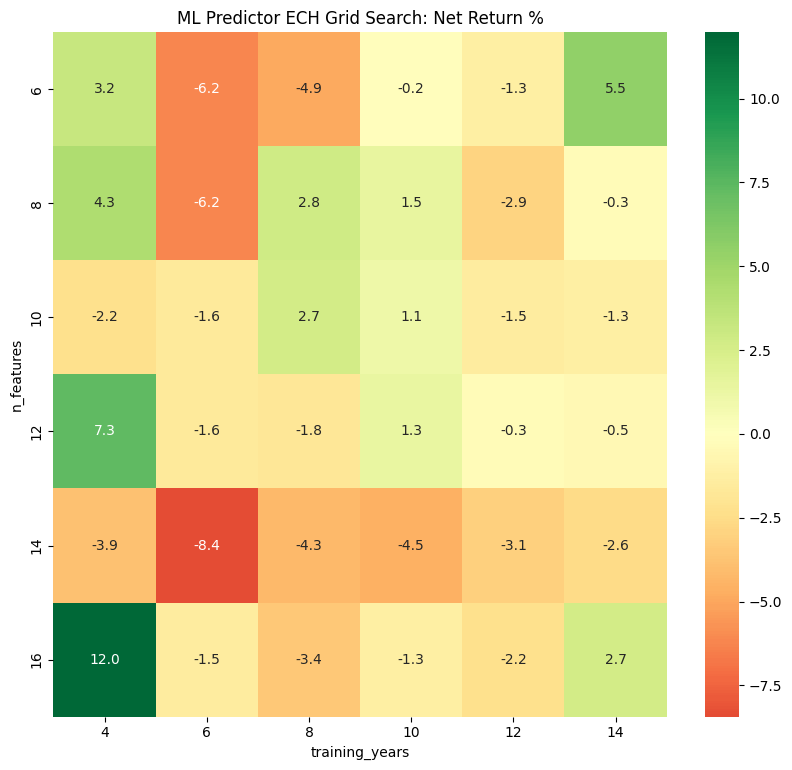

In [34]:
grid_1_parameter_grid_frozen_njobs1 = run_parameter_grid_search_frozen(
    raw_ohlcv,
    symbol=FIXED["symbol"],
    **GRID_1,
    n_jobs=1,
    verbose=50,
    **GRID_1_FIXED,
)
grid_1_parameter_grid_frozen_njobs1

In [35]:
grid_1_direct_vs_parameter_grid_njobs1_diffs = compare_results(
    grid_1_direct_frozen,
    grid_1_parameter_grid_frozen_njobs1,
    "direct_frozen",
    "parameter_grid_frozen_njobs1",
)

PASS: direct_frozen and parameter_grid_frozen_njobs1 match within atol=1e-09, rtol=1e-09.


[Parallel(n_jobs=2)]: Using backend LokyBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done   1 tasks      | elapsed:   28.3s
[Parallel(n_jobs=2)]: Done   2 tasks      | elapsed:   36.9s
[Parallel(n_jobs=2)]: Done   3 tasks      | elapsed:   59.0s
[Parallel(n_jobs=2)]: Done   4 tasks      | elapsed:  1.2min
[Parallel(n_jobs=2)]: Done   5 tasks      | elapsed:  1.5min
[Parallel(n_jobs=2)]: Done   6 tasks      | elapsed:  1.8min
[Parallel(n_jobs=2)]: Done   7 tasks      | elapsed:  1.9min
[Parallel(n_jobs=2)]: Done   8 tasks      | elapsed:  2.4min
[Parallel(n_jobs=2)]: Done   9 tasks      | elapsed:  2.4min
[Parallel(n_jobs=2)]: Done  10 tasks      | elapsed:  2.8min
[Parallel(n_jobs=2)]: Done  11 tasks      | elapsed:  3.1min
[Parallel(n_jobs=2)]: Done  12 tasks      | elapsed:  3.6min
[Parallel(n_jobs=2)]: Done  13 tasks      | elapsed:  3.6min
[Parallel(n_jobs=2)]: Done  14 tasks      | elapsed:  4.2min
[Parallel(n_jobs=2)]: Done  15 tasks      | elapsed:  4.3min
[Parallel(

,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,verbose,show_progress,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2025-01-01,2025-03-01,0.002,6,4,1.0,5000,False,False,1,3.224502,3.786238,1.032245e+06,1.037862e+06
1,ECH,2025-01-01,2025-03-01,0.002,6,6,1.0,5000,False,False,1,-6.234143,-5.887879,9.376586e+05,9.411212e+05
2,ECH,2025-01-01,2025-03-01,0.002,6,8,1.0,5000,False,False,1,-4.888975,-4.025526,9.511103e+05,9.597447e+05
3,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,False,False,1,-0.188071,0.445721,9.981193e+05,1.004457e+06
4,ECH,2025-01-01,2025-03-01,0.002,6,12,1.0,5000,False,False,1,-1.286149,-0.460287,9.871385e+05,9.953971e+05
5,ECH,2025-01-01,2025-03-01,0.002,6,14,1.0,5000,False,False,1,5.521885,6.075868,1.055219e+06,1.060759e+06
6,ECH,2025-01-01,2025-03-01,0.002,8,4,1.0,5000,False,False,1,4.327975,4.688843,1.043280e+06,1.046888e+06
7,ECH,2025-01-01,2025-03-01,0.002,8,6,1.0,5000,False,False,1,-6.234143,-5.887879,9.376586e+05,9.411212e+05
8,ECH,2025-01-01,2025-03-01,0.002,8,8,1.0,5000,False,False,1,2.809860,3.557338,1.028099e+06,1.035573e+06
9,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,False,False,1,1.494653,2.135350,1.014947e+06,1.021354e+06


PASS: parameter_grid_frozen_njobs1 and parameter_grid_frozen_njobs2 match within atol=1e-09, rtol=1e-09.


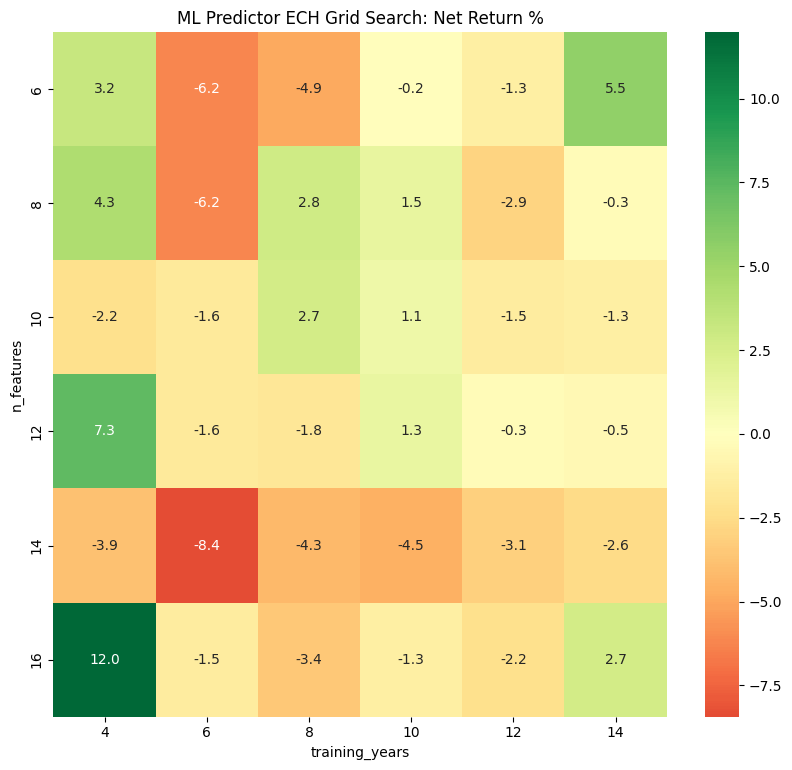

In [36]:
# Optional: run the same frozen parameter_grid_search with multiple workers.
grid_1_parameter_grid_frozen_njobs2 = run_parameter_grid_search_frozen(
    raw_ohlcv,
    symbol=FIXED["symbol"],
    **GRID_1,
    n_jobs=2,
    verbose=50,
    **GRID_1_FIXED,
)

grid_1_parameter_grid_njobs1_vs_njobs2_diffs = compare_results(
    grid_1_parameter_grid_frozen_njobs1,
    grid_1_parameter_grid_frozen_njobs2,
    "parameter_grid_frozen_njobs1",
    "parameter_grid_frozen_njobs2",
)

In [37]:
# Test if parameter_grid_search with n_jobs=2 produces the same results as the direct frozen run.
grid_1_direct_vs_parameter_grid_njobs2_diffs = compare_results(
    grid_1_direct_frozen,
    grid_1_parameter_grid_frozen_njobs2,
    "direct_frozen",
    "parameter_grid_frozen_njobs2",
)

PASS: direct_frozen and parameter_grid_frozen_njobs2 match within atol=1e-09, rtol=1e-09.


In [38]:
grid_1_parameter_grid_njobs1_vs_njobs2_diffs = compare_results(
    grid_1_parameter_grid_frozen_njobs1,
    grid_1_parameter_grid_frozen_njobs2,
    "parameter_grid_frozen_njobs1",
    "parameter_grid_frozen_njobs2",
)

PASS: parameter_grid_frozen_njobs1 and parameter_grid_frozen_njobs2 match within atol=1e-09, rtol=1e-09.


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.
[Parallel(n_jobs=-1)]: Done   1 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:  1.4min
[Parallel(n_jobs=-1)]: Done   3 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done   4 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done   5 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done   6 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done   8 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:  2.4min
[Parallel(n_jobs=-1)]: Done  10 tasks      | elapsed:  2.6min
[Parallel(n_jobs=-1)]: Done  11 tasks      | elapsed:  2.8min
[Parallel(n_jobs=-1)]: Done  12 tasks      | elapsed:  3.1min
[Parallel(n_jobs=-1)]: Done  13 tasks      | elapsed:  3.2min
[Parallel(n_jobs=-1)]: Done  14 tasks      | elapsed:  3.4min
[Parallel(n_jobs=-1)]: Done  15 tasks      | elapsed:  3

,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,verbose,show_progress,execution_delay,net_return_pct,gross_return_pct,final_net_equity,final_gross_equity
0,ECH,2025-01-01,2025-03-01,0.002,6,4,1.0,5000,False,False,1,3.224502,3.786238,1.032245e+06,1.037862e+06
1,ECH,2025-01-01,2025-03-01,0.002,6,6,1.0,5000,False,False,1,-6.234143,-5.887879,9.376586e+05,9.411212e+05
2,ECH,2025-01-01,2025-03-01,0.002,6,8,1.0,5000,False,False,1,-4.888975,-4.025526,9.511103e+05,9.597447e+05
3,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,False,False,1,-0.188071,0.445721,9.981193e+05,1.004457e+06
4,ECH,2025-01-01,2025-03-01,0.002,6,12,1.0,5000,False,False,1,-1.286149,-0.460287,9.871385e+05,9.953971e+05
5,ECH,2025-01-01,2025-03-01,0.002,6,14,1.0,5000,False,False,1,5.521885,6.075868,1.055219e+06,1.060759e+06
6,ECH,2025-01-01,2025-03-01,0.002,8,4,1.0,5000,False,False,1,4.327975,4.688843,1.043280e+06,1.046888e+06
7,ECH,2025-01-01,2025-03-01,0.002,8,6,1.0,5000,False,False,1,-6.234143,-5.887879,9.376586e+05,9.411212e+05
8,ECH,2025-01-01,2025-03-01,0.002,8,8,1.0,5000,False,False,1,2.809860,3.557338,1.028099e+06,1.035573e+06
9,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,False,False,1,1.494653,2.135350,1.014947e+06,1.021354e+06


PASS: direct_frozen and parameter_grid_frozen_njobsN1 match within atol=1e-09, rtol=1e-09.


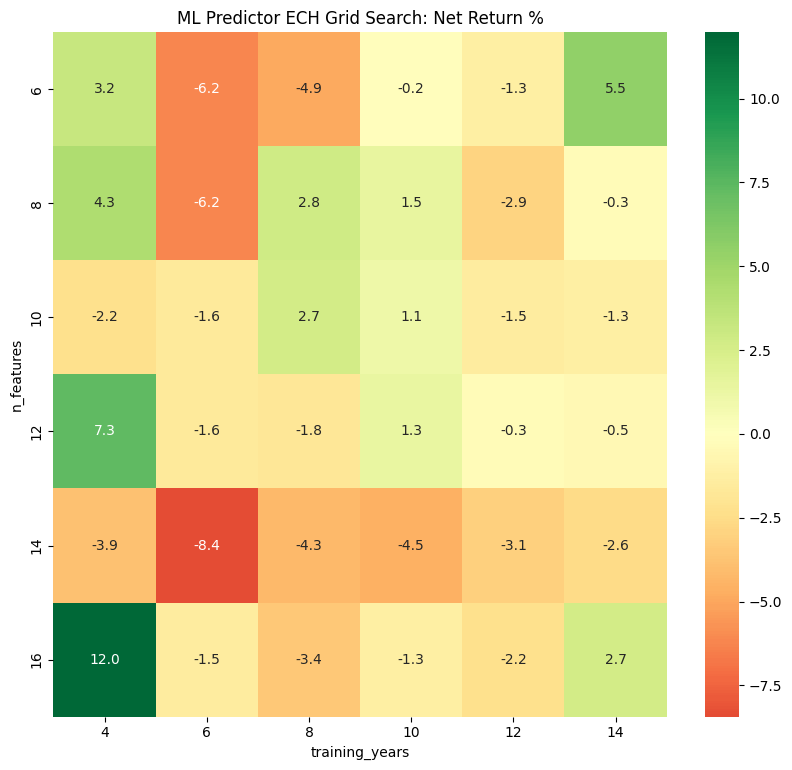

In [39]:
# Optional: run the same frozen parameter_grid_search with multiple workers.
grid_1_parameter_grid_frozen_njobsN1 = run_parameter_grid_search_frozen(
    raw_ohlcv,
    symbol=FIXED["symbol"],
    **GRID_1,
    n_jobs=-1,
    verbose=50,
    **GRID_1_FIXED,
)

grid_1_direct_vs_parameter_grid_njobsN1_diffs = compare_results(
    grid_1_direct_frozen,
    grid_1_parameter_grid_frozen_njobsN1,
    "direct_frozen",
    "parameter_grid_frozen_njobsN1",
)

### Grid 2: `signal_threshold` vs `training_years`

This mirrors the other grid that overlapped with the first one at `n_features=12`.

In [ ]:
GRID_2 = dict(
    var_1="signal_threshold",
    list_1=[0.001, 0.002, 0.003, 0.004, 0.005],
    var_2="training_years",
    list_2=[4, 6, 8, 10, 12, 14],
)

GRID_2_FIXED = dict(
    asset_class=FIXED["asset_class"],
    start_date=FIXED["start_date"],
    end_date=FIXED["end_date"],
    n_features=12,
    position_size=FIXED["position_size"],
    initial_capital=FIXED["initial_capital"],
    max_iter=FIXED["max_iter"],
    execution_delay=FIXED["execution_delay"],
    show_progress=FIXED["show_progress"],
)

grid_2_cases = cases_from_grid(**GRID_2)
grid_2_cases_df = pd.DataFrame(grid_2_cases)
grid_2_cases_df

In [ ]:
grid_2_direct_cases = [{**case, "n_features": GRID_2_FIXED["n_features"]} for case in grid_2_cases]
grid_2_direct_frozen = run_loky_frozen(raw_ohlcv, grid_2_direct_cases, n_jobs=1)
grid_2_direct_frozen

In [ ]:
grid_2_parameter_grid_frozen_njobs1 = run_parameter_grid_search_frozen(
    raw_ohlcv,
    symbol=FIXED["symbol"],
    **GRID_2,
    n_jobs=1,
    verbose=50,
    **GRID_2_FIXED,
)
grid_2_parameter_grid_frozen_njobs1

In [ ]:
grid_2_direct_vs_parameter_grid_njobs1_diffs = compare_results(
    grid_2_direct_frozen,
    grid_2_parameter_grid_frozen_njobs1,
    "direct_frozen",
    "parameter_grid_frozen_njobs1",
)

In [ ]:
# Optional: run the same frozen parameter_grid_search with multiple workers.
grid_2_parameter_grid_frozen_njobs2 = run_parameter_grid_search_frozen(
    raw_ohlcv,
    symbol=FIXED["symbol"],
    **GRID_2,
    n_jobs=2,
    verbose=50,
    **GRID_2_FIXED,
)

grid_2_parameter_grid_njobs1_vs_njobs2_diffs = compare_results(
    grid_2_parameter_grid_frozen_njobs1,
    grid_2_parameter_grid_frozen_njobs2,
    "parameter_grid_frozen_njobs1",
    "parameter_grid_frozen_njobs2",
)

## 9. Fresh-download `parameter_grid_search` Data Audit

This section runs an instrumented `parameter_grid_search(..., n_jobs=-1)` where each case downloads its own Yahoo data, like the standard grid-search path. The worker records whether the freshly downloaded raw OHLCV data matches the corresponding slice of the frozen `raw_ohlcv` dataset, and whether the resulting returns match the frozen-input baseline.

### Fresh-download audit helpers

These helpers compare raw downloads before indicator computation. That isolates the external data collection step from the local processing step.

In [27]:
import hashlib

from IPython.display import display as ipy_display
from pandas.testing import assert_frame_equal


def canonical_raw_ohlcv(df):
    out = df.copy()
    if isinstance(out.columns, pd.MultiIndex):
        out.columns = out.columns.get_level_values(0)
    out = out[["Open", "High", "Low", "Close", "Volume"]].copy()
    out = out.sort_index()
    out.index = pd.to_datetime(out.index).tz_localize(None)
    return out


def raw_ohlcv_fingerprint(df):
    canonical = canonical_raw_ohlcv(df)
    hasher = hashlib.sha256()
    hasher.update(str(list(canonical.columns)).encode("utf-8"))
    hasher.update(pd.util.hash_pandas_object(canonical, index=True).values.tobytes())
    return hasher.hexdigest()


def expected_frozen_raw_window(raw_ohlcv, params):
    indicator_warmup_years = params.get("indicator_warmup_years", 1)
    start_download = pd.to_datetime(params["start_date"]) - pd.DateOffset(
        years=params["training_years"] + indicator_warmup_years
    )
    end_exclusive = pd.to_datetime(params["end_date"])

    frozen = canonical_raw_ohlcv(raw_ohlcv)
    return frozen.loc[(frozen.index >= start_download) & (frozen.index < end_exclusive)].copy()


def compare_raw_download_to_frozen(downloaded_raw, raw_ohlcv, params, atol=1e-10, rtol=1e-10):
    downloaded = canonical_raw_ohlcv(downloaded_raw)
    expected = expected_frozen_raw_window(raw_ohlcv, params)

    shape_matches = downloaded.shape == expected.shape
    columns_match = list(downloaded.columns) == list(expected.columns)
    index_matches = downloaded.index.equals(expected.index)

    values_match = False
    max_abs_diff = np.nan
    differing_cells = np.nan

    common_index = downloaded.index.intersection(expected.index)
    common_columns = downloaded.columns.intersection(expected.columns)
    if len(common_index) and len(common_columns):
        downloaded_common = downloaded.loc[common_index, common_columns]
        expected_common = expected.loc[common_index, common_columns]
        numeric_diff = (downloaded_common - expected_common).abs()
        max_abs_diff = float(numeric_diff.max().max())
        differing_cells = int((numeric_diff > atol).sum().sum())

    if shape_matches and columns_match and index_matches:
        try:
            assert_frame_equal(
                downloaded,
                expected,
                check_dtype=False,
                check_exact=False,
                atol=atol,
                rtol=rtol,
            )
            values_match = True
        except AssertionError:
            values_match = False

    data_matches_frozen = bool(shape_matches and columns_match and index_matches and values_match)

    return {
        "raw_download_fingerprint": raw_ohlcv_fingerprint(downloaded),
        "raw_frozen_fingerprint": raw_ohlcv_fingerprint(expected),
        "data_matches_frozen": data_matches_frozen,
        "raw_shape_matches": bool(shape_matches),
        "raw_columns_match": bool(columns_match),
        "raw_index_matches": bool(index_matches),
        "raw_values_match": bool(values_match),
        "raw_download_rows": len(downloaded),
        "raw_frozen_rows": len(expected),
        "raw_download_start": downloaded.index.min(),
        "raw_download_end": downloaded.index.max(),
        "raw_frozen_start": expected.index.min(),
        "raw_frozen_end": expected.index.max(),
        "raw_common_rows": len(common_index),
        "raw_max_abs_diff": max_abs_diff,
        "raw_differing_cells": differing_cells,
    }


def frozen_return_lookup_from_results(frozen_results_df):
    lookup = {}
    for _, row in frozen_results_df.iterrows():
        key = (
            row["symbol"],
            row["start_date"],
            row["end_date"],
            float(row["signal_threshold"]),
            int(row["n_features"]),
            int(row["training_years"]),
            float(row["position_size"]),
            int(row["max_iter"]),
            int(row["execution_delay"]),
        )
        lookup[key] = {
            "frozen_net_return_pct": float(row["net_return_pct"]),
            "frozen_gross_return_pct": float(row["gross_return_pct"]),
            "frozen_final_net_equity": float(row["final_net_equity"]),
            "frozen_final_gross_equity": float(row["final_gross_equity"]),
        }
    return lookup


def result_key_from_params(params):
    return (
        params["symbol"],
        params["start_date"],
        params["end_date"],
        float(params["signal_threshold"]),
        int(params["n_features"]),
        int(params["training_years"]),
        float(params["position_size"]),
        int(params["max_iter"]),
        int(params["execution_delay"]),
    )

In [28]:
def run_grid_case_fresh_download_audit(
    raw_ohlcv,
    frozen_return_lookup,
    symbol,
    asset_class="STK",
    start_date="2025-01-01",
    end_date="2025-03-01",
    signal_threshold=0.002,
    n_features=6,
    training_years=10,
    position_size=1.0,
    initial_capital=1_000_000,
    max_iter=5000,
    execution_delay=1,
    verbose=False,
    show_progress=False,
    return_tolerance=1e-8,
):
    params = {
        "symbol": symbol,
        "start_date": start_date,
        "end_date": end_date,
        "signal_threshold": signal_threshold,
        "n_features": n_features,
        "training_years": training_years,
        "position_size": position_size,
        "max_iter": max_iter,
        "verbose": verbose,
        "show_progress": show_progress,
    }

    full_params = {
        **params,
        "asset_class": asset_class,
        "initial_capital": initial_capital,
        "execution_delay": execution_delay,
    }

    strategy = MLPredictorStrategy(params=params)

    # This is the fresh external data call being tested.
    downloaded_raw = strategy.download_dataset()
    data_audit = compare_raw_download_to_frozen(downloaded_raw, raw_ohlcv, full_params)

    # Continue with the same local processing path as prepare_dataset(), but using the captured raw download.
    dataset = strategy.assign_signal(downloaded_raw.copy())
    dataset = strategy.compute_technical_indicators(dataset).copy()
    dataset = strategy.clean_dataset(dataset)
    weights = strategy.generate_signals(dataset, show_progress=show_progress)
    if weights.empty:
        return None

    prices = dataset[["Open"]].rename(columns={"Open": symbol}).loc[weights.index]
    engine = PortfolioVectorEngine(
        prices=prices,
        signals=weights,
        asset_class=asset_class,
        initial_capital=initial_capital,
        execution_delay=execution_delay,
    )
    stats = engine.run()

    net_return_pct = (stats["net_equity"].iloc[-1] / initial_capital - 1) * 100
    gross_return_pct = (stats["gross_equity"].iloc[-1] / initial_capital - 1) * 100
    final_net_equity = stats["net_equity"].iloc[-1]
    final_gross_equity = stats["gross_equity"].iloc[-1]

    frozen_result = frozen_return_lookup.get(result_key_from_params(full_params), {})
    frozen_net_return_pct = frozen_result.get("frozen_net_return_pct", np.nan)
    frozen_gross_return_pct = frozen_result.get("frozen_gross_return_pct", np.nan)
    frozen_final_net_equity = frozen_result.get("frozen_final_net_equity", np.nan)
    frozen_final_gross_equity = frozen_result.get("frozen_final_gross_equity", np.nan)

    net_return_diff = net_return_pct - frozen_net_return_pct
    gross_return_diff = gross_return_pct - frozen_gross_return_pct
    net_return_matches_frozen = bool(np.isfinite(net_return_diff) and abs(net_return_diff) <= return_tolerance)
    gross_return_matches_frozen = bool(np.isfinite(gross_return_diff) and abs(gross_return_diff) <= return_tolerance)

    return {
        **params,
        "execution_delay": execution_delay,
        "net_return_pct": net_return_pct,
        "gross_return_pct": gross_return_pct,
        "final_net_equity": final_net_equity,
        "final_gross_equity": final_gross_equity,
        **frozen_result,
        "net_return_diff_vs_frozen": net_return_diff,
        "gross_return_diff_vs_frozen": gross_return_diff,
        "net_return_matches_frozen": net_return_matches_frozen,
        "gross_return_matches_frozen": gross_return_matches_frozen,
        **data_audit,
    }


def run_parameter_grid_search_fresh_download_audit(
    raw_ohlcv,
    frozen_results_df,
    *,
    symbol,
    var_1,
    list_1,
    var_2,
    list_2,
    n_jobs=-1,
    grid_verbose=50,
    **extra_kwargs,
):
    run_grid_case_module = sys.modules["run_grid_case"]
    frozen_return_lookup = frozen_return_lookup_from_results(frozen_results_df)

    captured_displays = []
    original_run_grid_case = run_grid_case_module.run_grid_case
    original_display = run_grid_case_module.display
    original_show = run_grid_case_module.plt.show

    def audit_adapter(**kwargs):
        return run_grid_case_fresh_download_audit(raw_ohlcv, frozen_return_lookup, **kwargs)

    def capture_display(obj):
        if isinstance(obj, pd.DataFrame):
            captured_displays.append(obj.copy())
        ipy_display(obj)

    try:
        run_grid_case_module.run_grid_case = audit_adapter
        run_grid_case_module.display = capture_display
        run_grid_case_module.plt.show = lambda *args, **kwargs: None

        run_grid_case_module.parameter_grid_search(
            symbol=symbol,
            var_1=var_1,
            list_1=list_1,
            var_2=var_2,
            list_2=list_2,
            n_jobs=n_jobs,
            verbose=grid_verbose,
            **extra_kwargs,
        )
    finally:
        run_grid_case_module.run_grid_case = original_run_grid_case
        run_grid_case_module.display = original_display
        run_grid_case_module.plt.show = original_show
        get_reusable_executor().shutdown(wait=True)

    if not captured_displays:
        raise RuntimeError("parameter_grid_search did not display a DataFrame to capture.")

    df = captured_displays[0].sort_values([var_1, var_2]).reset_index(drop=True).copy()
    df["case_id"] = range(len(df))
    return df

### Single redownload sanity check

This repeats the same one-shot download used to create `raw_ohlcv` for the frozen-input tests, then compares the new download against the original frozen raw data. If this passes, ordinary single downloads are stable; if it fails, the data source can vary even without parallel workers.

In [13]:
def compare_raw_downloads(left_raw, right_raw, left_name="original_frozen", right_name="single_redownload", atol=1e-10, rtol=1e-10):
    left = canonical_raw_ohlcv(left_raw)
    right = canonical_raw_ohlcv(right_raw)

    shape_matches = left.shape == right.shape
    columns_match = list(left.columns) == list(right.columns)
    index_matches = left.index.equals(right.index)
    fingerprint_matches = raw_ohlcv_fingerprint(left) == raw_ohlcv_fingerprint(right)

    common_index = left.index.intersection(right.index)
    common_columns = left.columns.intersection(right.columns)
    max_abs_diff = np.nan
    differing_cells = np.nan

    if len(common_index) and len(common_columns):
        diff = (left.loc[common_index, common_columns] - right.loc[common_index, common_columns]).abs()
        max_abs_diff = float(diff.max().max())
        differing_cells = int((diff > atol).sum().sum())

    values_match = False
    if shape_matches and columns_match and index_matches:
        try:
            assert_frame_equal(
                left,
                right,
                check_dtype=False,
                check_exact=False,
                atol=atol,
                rtol=rtol,
            )
            values_match = True
        except AssertionError:
            values_match = False

    summary = pd.DataFrame([
        {
            "left_name": left_name,
            "right_name": right_name,
            "shape_matches": shape_matches,
            "columns_match": columns_match,
            "index_matches": index_matches,
            "values_match": values_match,
            "fingerprint_matches": fingerprint_matches,
            "left_rows": len(left),
            "right_rows": len(right),
            "left_start": left.index.min(),
            "left_end": left.index.max(),
            "right_start": right.index.min(),
            "right_end": right.index.max(),
            "common_rows": len(common_index),
            "max_abs_diff": max_abs_diff,
            "differing_cells": differing_cells,
            "left_fingerprint": raw_ohlcv_fingerprint(left),
            "right_fingerprint": raw_ohlcv_fingerprint(right),
        }
    ])

    return summary


raw_ohlcv_single_redownload = download_frozen_raw(FIXED, CASES)
single_redownload_comparison = compare_raw_downloads(raw_ohlcv, raw_ohlcv_single_redownload)
single_redownload_comparison

,left_name,right_name,shape_matches,columns_match,index_matches,values_match,fingerprint_matches,left_rows,right_rows,left_start,left_end,right_start,right_end,common_rows,max_abs_diff,differing_cells,left_fingerprint,right_fingerprint
0,original_frozen,single_redownload,True,True,True,True,True,3813,3813,2010-01-04,2025-02-28,2010-01-04,2025-02-28,3813,0.0,0,d9f9b12da44b9eb4f1ba574b19378f6a6deeb7c40e06f6...,d9f9b12da44b9eb4f1ba574b19378f6a6deeb7c40e06f6...


In [14]:
if bool(single_redownload_comparison["fingerprint_matches"].iloc[0]):
    print("PASS: the repeated single download matches the original frozen raw data.")
else:
    print("FAIL: the repeated single download differs from the original frozen raw data.")
    display(single_redownload_comparison.T)

PASS: the repeated single download matches the original frozen raw data.


### Run the fresh-download audit grid

This uses the same Grid 1 specification as Section 8, but now each case downloads Yahoo data anew. The frozen Grid 1 result is used as the baseline for return comparisons.

[Parallel(n_jobs=1)]: Done   1 tasks      | elapsed:   25.6s
[Parallel(n_jobs=1)]: Done   2 tasks      | elapsed:  1.0min
[Parallel(n_jobs=1)]: Done   3 tasks      | elapsed:  1.5min
[Parallel(n_jobs=1)]: Done   4 tasks      | elapsed:  2.0min
[Parallel(n_jobs=1)]: Done   5 tasks      | elapsed:  2.6min
[Parallel(n_jobs=1)]: Done   6 tasks      | elapsed:  3.2min
[Parallel(n_jobs=1)]: Done   7 tasks      | elapsed:  3.6min
[Parallel(n_jobs=1)]: Done   8 tasks      | elapsed:  4.3min
[Parallel(n_jobs=1)]: Done   9 tasks      | elapsed:  4.8min
[Parallel(n_jobs=1)]: Done  10 tasks      | elapsed:  5.2min
[Parallel(n_jobs=1)]: Done  11 tasks      | elapsed:  5.8min
[Parallel(n_jobs=1)]: Done  12 tasks      | elapsed:  6.4min
[Parallel(n_jobs=1)]: Done  13 tasks      | elapsed:  6.9min
[Parallel(n_jobs=1)]: Done  14 tasks      | elapsed:  7.5min
[Parallel(n_jobs=1)]: Done  15 tasks      | elapsed:  8.0min
[Parallel(n_jobs=1)]: Done  16 tasks      | elapsed:  8.7min
[Parallel(n_jobs=1)]: Do

/opt/miniconda3/envs/bluegrey/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[Parallel(n_jobs=-1)]: Done  24 out of  36 | elapsed:  5.9min remaining:  2.9min
[Parallel(n_jobs=-1)]: Done  25 out of  36 | elapsed:  6.1min remaining:  2.7min
[Parallel(n_jobs=-1)]: Done  26 out of  36 | elapsed:  6.1min remaining:  2.3min
[Parallel(n_jobs=-1)]: Done  27 out of  36 | elapsed:  6.8min remaining:  2.3min
[Parallel(n_jobs=-1)]: Done  28 out of  36 | elapsed:  6.8min remaining:  1.9min
[Parallel(n_jobs=-1)]: Done  29 out of  36 | elapsed:  6.9min remaining:  1.7min
[Parallel(n_jobs=-1)]: Done  30 out of  36 | elapsed:  7.5min remaining:  1.5min
[Parallel(n_jobs=-1)]: Done  31 out of  36 | elapsed:  7.6min remaining:  1.2min
[Parallel(n_jobs=-1)]: Done  32 out of  36 | elapsed:  7.7min remaining:   57.8s
[Parallel(n_jobs=-1)]: Done  33 out of  36 | elapsed:  7.9min remaining:   42.8s
[Parallel(n_jobs=-1)]: Done  34 out of  36 | elapsed:  8.1min remaining:   28.7s
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:  8.5min finished


,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,verbose,show_progress,...,raw_values_match,raw_download_rows,raw_frozen_rows,raw_download_start,raw_download_end,raw_frozen_start,raw_frozen_end,raw_common_rows,raw_max_abs_diff,raw_differing_cells
0,ECH,2025-01-01,2025-03-01,0.002,6,4,1.0,5000,False,False,...,False,1297,1297,2020-01-02,2025-02-28,2020-01-02,2025-02-28,1297,0.000008,3444
1,ECH,2025-01-01,2025-03-01,0.002,6,6,1.0,5000,False,False,...,False,1800,1800,2018-01-02,2025-02-28,2018-01-02,2025-02-28,1800,0.000015,4956
2,ECH,2025-01-01,2025-03-01,0.002,6,8,1.0,5000,False,False,...,False,2303,2303,2016-01-04,2025-02-28,2016-01-04,2025-02-28,2303,0.000019,6488
3,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,False,False,...,False,2807,2807,2014-01-02,2025-02-28,2014-01-02,2025-02-28,2807,0.000019,8388
4,ECH,2025-01-01,2025-03-01,0.002,6,12,1.0,5000,False,False,...,False,3309,3309,2012-01-03,2025-02-28,2012-01-03,2025-02-28,3309,0.000023,9936
5,ECH,2025-01-01,2025-03-01,0.002,6,14,1.0,5000,False,False,...,False,3813,3813,2010-01-04,2025-02-28,2010-01-04,2025-02-28,3813,0.000023,11556
6,ECH,2025-01-01,2025-03-01,0.002,8,4,1.0,5000,False,False,...,False,1297,1297,2020-01-02,2025-02-28,2020-01-02,2025-02-28,1297,0.000010,3424
7,ECH,2025-01-01,2025-03-01,0.002,8,6,1.0,5000,False,False,...,False,1800,1800,2018-01-02,2025-02-28,2018-01-02,2025-02-28,1800,0.000015,5156
8,ECH,2025-01-01,2025-03-01,0.002,8,8,1.0,5000,False,False,...,False,2303,2303,2016-01-04,2025-02-28,2016-01-04,2025-02-28,2303,0.000016,6468
9,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,False,False,...,False,2807,2807,2014-01-02,2025-02-28,2014-01-02,2025-02-28,2807,0.000019,8264


,symbol,start_date,end_date,signal_threshold,n_features,training_years,position_size,max_iter,verbose,show_progress,...,raw_download_rows,raw_frozen_rows,raw_download_start,raw_download_end,raw_frozen_start,raw_frozen_end,raw_common_rows,raw_max_abs_diff,raw_differing_cells,case_id
0,ECH,2025-01-01,2025-03-01,0.002,6,4,1.0,5000,False,False,...,1297,1297,2020-01-02,2025-02-28,2020-01-02,2025-02-28,1297,0.000008,3444,0
1,ECH,2025-01-01,2025-03-01,0.002,6,6,1.0,5000,False,False,...,1800,1800,2018-01-02,2025-02-28,2018-01-02,2025-02-28,1800,0.000015,4956,1
2,ECH,2025-01-01,2025-03-01,0.002,6,8,1.0,5000,False,False,...,2303,2303,2016-01-04,2025-02-28,2016-01-04,2025-02-28,2303,0.000019,6488,2
3,ECH,2025-01-01,2025-03-01,0.002,6,10,1.0,5000,False,False,...,2807,2807,2014-01-02,2025-02-28,2014-01-02,2025-02-28,2807,0.000019,8388,3
4,ECH,2025-01-01,2025-03-01,0.002,6,12,1.0,5000,False,False,...,3309,3309,2012-01-03,2025-02-28,2012-01-03,2025-02-28,3309,0.000023,9936,4
5,ECH,2025-01-01,2025-03-01,0.002,6,14,1.0,5000,False,False,...,3813,3813,2010-01-04,2025-02-28,2010-01-04,2025-02-28,3813,0.000023,11556,5
6,ECH,2025-01-01,2025-03-01,0.002,8,4,1.0,5000,False,False,...,1297,1297,2020-01-02,2025-02-28,2020-01-02,2025-02-28,1297,0.000010,3424,6
7,ECH,2025-01-01,2025-03-01,0.002,8,6,1.0,5000,False,False,...,1800,1800,2018-01-02,2025-02-28,2018-01-02,2025-02-28,1800,0.000015,5156,7
8,ECH,2025-01-01,2025-03-01,0.002,8,8,1.0,5000,False,False,...,2303,2303,2016-01-04,2025-02-28,2016-01-04,2025-02-28,2303,0.000016,6468,8
9,ECH,2025-01-01,2025-03-01,0.002,8,10,1.0,5000,False,False,...,2807,2807,2014-01-02,2025-02-28,2014-01-02,2025-02-28,2807,0.000019,8264,9


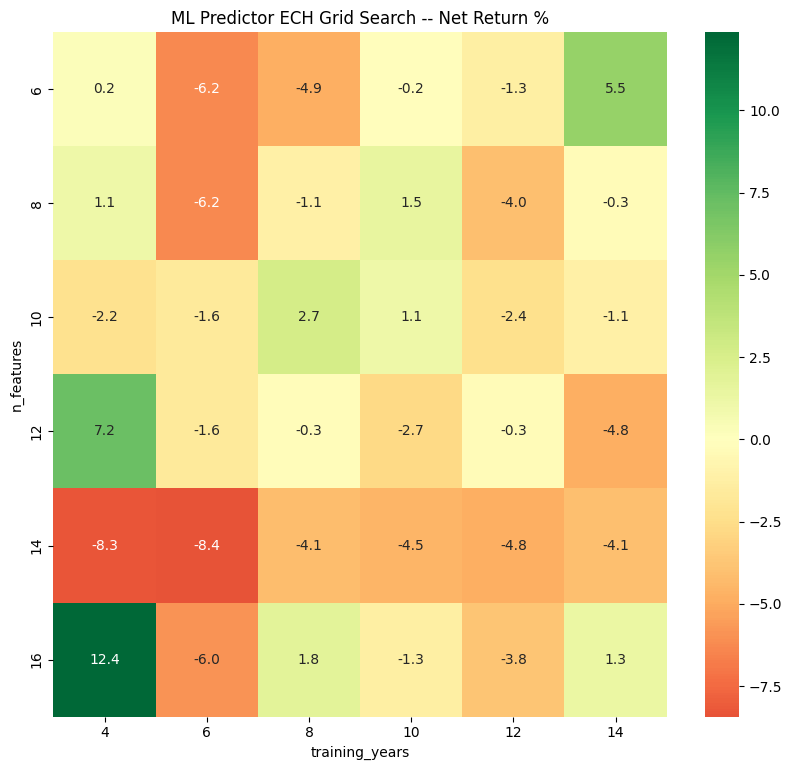

In [29]:
try:
    grid_1_frozen_baseline = grid_1_direct_frozen
except NameError:
    grid_1_frozen_baseline = run_loky_frozen(raw_ohlcv, grid_1_cases, n_jobs=1)

grid_1_fresh_download_audit = run_parameter_grid_search_fresh_download_audit(
    raw_ohlcv,
    grid_1_frozen_baseline,
    symbol=FIXED["symbol"],
    **GRID_1,
    n_jobs=-1,
    grid_verbose=50,
    **GRID_1_FIXED,
)

grid_1_fresh_download_audit

### Data-match and return-match grids

The first grid shows whether each fresh Yahoo download matches the corresponding frozen raw data window. The second grid shows whether the resulting net return matches the frozen-input net return for the same parameters.

In [30]:
data_match_grid = grid_1_fresh_download_audit.pivot(
    index=GRID_1["var_1"],
    columns=GRID_1["var_2"],
    values="data_matches_frozen",
)

net_return_match_grid = grid_1_fresh_download_audit.pivot(
    index=GRID_1["var_1"],
    columns=GRID_1["var_2"],
    values="net_return_matches_frozen",
)

print("Fresh downloaded raw data matches frozen raw data:")
display(data_match_grid)

print("Fresh-download net return matches frozen-input net return:")
display(net_return_match_grid)

Fresh downloaded raw data matches frozen raw data:


training_years,4,6,8,10,12,14
n_features,,,,,,
6,False,False,False,False,False,False
8,False,False,False,False,False,False
10,False,False,False,False,False,False
12,False,False,False,False,False,False
14,False,False,False,False,False,False
16,False,False,False,False,False,False


Fresh-download net return matches frozen-input net return:


training_years,4,6,8,10,12,14
n_features,,,,,,
6,False,False,False,False,False,False
8,False,False,False,False,False,False
10,False,False,False,False,False,False
12,False,False,False,False,False,False
14,False,False,False,False,False,False
16,False,False,False,False,False,False


In [31]:
relationship_grid = grid_1_fresh_download_audit.copy()
relationship_grid["data_result_relationship"] = np.select(
    [
        relationship_grid["data_matches_frozen"] & relationship_grid["net_return_matches_frozen"],
        relationship_grid["data_matches_frozen"] & ~relationship_grid["net_return_matches_frozen"],
        ~relationship_grid["data_matches_frozen"] & relationship_grid["net_return_matches_frozen"],
        ~relationship_grid["data_matches_frozen"] & ~relationship_grid["net_return_matches_frozen"],
    ],
    [
        "data match / return match",
        "DATA MATCH / RETURN DIFF",
        "DATA DIFF / RETURN MATCH",
        "data diff / return diff",
    ],
    default="unclassified",
)

relationship_status_grid = relationship_grid.pivot(
    index=GRID_1["var_1"],
    columns=GRID_1["var_2"],
    values="data_result_relationship",
)

relationship_status_grid

training_years,4,6,8,10,12,14
n_features,,,,,,
6,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff
8,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff
10,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff
12,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff
14,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff
16,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff,data diff / return diff


### Test the data-result relationship

This checks the hypothesis: cases whose data matches should also have matching returns, and cases whose data differs should also have differing returns.

In [32]:
data_result_crosstab = pd.crosstab(
    grid_1_fresh_download_audit["data_matches_frozen"],
    grid_1_fresh_download_audit["net_return_matches_frozen"],
    rownames=["data_matches_frozen"],
    colnames=["net_return_matches_frozen"],
    dropna=False,
)

data_result_violations = grid_1_fresh_download_audit[
    grid_1_fresh_download_audit["data_matches_frozen"] != grid_1_fresh_download_audit["net_return_matches_frozen"]
].copy()

relationship_hypothesis_holds = data_result_violations.empty

print("Data/return match crosstab:")
display(data_result_crosstab)

print(f"Relationship hypothesis holds: {relationship_hypothesis_holds}")

if not relationship_hypothesis_holds:
    display(
        data_result_violations[
            [
                GRID_1["var_1"],
                GRID_1["var_2"],
                "data_matches_frozen",
                "net_return_matches_frozen",
                "net_return_pct",
                "frozen_net_return_pct",
                "net_return_diff_vs_frozen",
                "raw_shape_matches",
                "raw_index_matches",
                "raw_values_match",
                "raw_download_rows",
                "raw_frozen_rows",
                "raw_common_rows",
                "raw_max_abs_diff",
                "raw_differing_cells",
            ]
        ]
    )

Data/return match crosstab:


net_return_matches_frozen,False
data_matches_frozen,
False,36


Relationship hypothesis holds: True


In [33]:
# Detailed audit columns for any case where the downloaded data differs.
data_mismatch_details = grid_1_fresh_download_audit[
    ~grid_1_fresh_download_audit["data_matches_frozen"]
].copy()

if data_mismatch_details.empty:
    print("All fresh downloads matched the frozen raw data windows.")
else:
    mismatch_columns = [
        GRID_1["var_1"],
        GRID_1["var_2"],
        "raw_shape_matches",
        "raw_columns_match",
        "raw_index_matches",
        "raw_values_match",
        "raw_download_rows",
        "raw_frozen_rows",
        "raw_download_start",
        "raw_download_end",
        "raw_frozen_start",
        "raw_frozen_end",
        "raw_common_rows",
        "raw_max_abs_diff",
        "raw_differing_cells",
    ]
    display(data_mismatch_details[mismatch_columns])

,n_features,training_years,raw_shape_matches,raw_columns_match,raw_index_matches,raw_values_match,raw_download_rows,raw_frozen_rows,raw_download_start,raw_download_end,raw_frozen_start,raw_frozen_end,raw_common_rows,raw_max_abs_diff,raw_differing_cells
0,6,4,True,True,True,False,1297,1297,2020-01-02,2025-02-28,2020-01-02,2025-02-28,1297,0.000008,3444
1,6,6,True,True,True,False,1800,1800,2018-01-02,2025-02-28,2018-01-02,2025-02-28,1800,0.000015,4956
2,6,8,True,True,True,False,2303,2303,2016-01-04,2025-02-28,2016-01-04,2025-02-28,2303,0.000019,6488
3,6,10,True,True,True,False,2807,2807,2014-01-02,2025-02-28,2014-01-02,2025-02-28,2807,0.000019,8388
4,6,12,True,True,True,False,3309,3309,2012-01-03,2025-02-28,2012-01-03,2025-02-28,3309,0.000023,9936
5,6,14,True,True,True,False,3813,3813,2010-01-04,2025-02-28,2010-01-04,2025-02-28,3813,0.000023,11556
6,8,4,True,True,True,False,1297,1297,2020-01-02,2025-02-28,2020-01-02,2025-02-28,1297,0.000010,3424
7,8,6,True,True,True,False,1800,1800,2018-01-02,2025-02-28,2018-01-02,2025-02-28,1800,0.000015,5156
8,8,8,True,True,True,False,2303,2303,2016-01-04,2025-02-28,2016-01-04,2025-02-28,2303,0.000016,6468
9,8,10,True,True,True,False,2807,2807,2014-01-02,2025-02-28,2014-01-02,2025-02-28,2807,0.000019,8264


### Which fresh downloads match each other?

This subsection fingerprints each raw Yahoo download. In Grid 1, downloads are expected to match across different `n_features` values when `training_years` is the same, because `n_features` should not affect the Yahoo date window. Downloads with different `training_years` usually should not match because the start date of the downloaded history changes.

In [34]:
if "raw_download_fingerprint" not in grid_1_fresh_download_audit.columns:
    raise RuntimeError(
        "This audit table does not include raw download fingerprints. "
        "Rerun the Section 9 helper cells and then rerun grid_1_fresh_download_audit."
    )

download_fingerprint_audit = grid_1_fresh_download_audit.copy()
download_fingerprint_audit["raw_download_fingerprint_short"] = download_fingerprint_audit[
    "raw_download_fingerprint"
].str.slice(0, 12)

download_fingerprint_grid = download_fingerprint_audit.pivot(
    index=GRID_1["var_1"],
    columns=GRID_1["var_2"],
    values="raw_download_fingerprint_short",
)

print("Raw download fingerprint by case. Equal fingerprints mean equal downloaded raw OHLCV data.")
display(download_fingerprint_grid)

Raw download fingerprint by case. Equal fingerprints mean equal downloaded raw OHLCV data.


training_years,4,6,8,10,12,14
n_features,,,,,,
6,8cc728c45394,6da9fe5bd635,90bf5c42a6f8,ba2bf48b0190,a1a1494ef743,c269d7330e72
8,430653f09a0f,112721ee086a,f10503a55cb1,fd038b2dd76a,a1a1494ef743,d3b41bb620a5
10,319d24cb0969,112721ee086a,90bf5c42a6f8,1352ac253c16,fc04d45102f0,fedc755160b6
12,319d24cb0969,d948c9691736,90bf5c42a6f8,7fa5c4ad9e66,bfb40a596238,c269d7330e72
14,319d24cb0969,12e3812324f9,f10503a55cb1,ba2bf48b0190,7471a3fbe663,bf9a0c1d46ca
16,3912d1ffd06e,12e3812324f9,409dd30923a0,1352ac253c16,d9f4ecb9c714,37ef51cd152e


In [35]:
download_groups = (
    download_fingerprint_audit
    .groupby("raw_download_fingerprint", dropna=False)
    .agg(
        fingerprint_short=("raw_download_fingerprint_short", "first"),
        cases=("raw_download_fingerprint", "size"),
        n_features_values=(GRID_1["var_1"], lambda s: sorted(s.unique().tolist())),
        training_years_values=(GRID_1["var_2"], lambda s: sorted(s.unique().tolist())),
        n_features_min=(GRID_1["var_1"], "min"),
        training_years_min=(GRID_1["var_2"], "min"),
        all_match_frozen=("data_matches_frozen", "all"),
        any_match_frozen=("data_matches_frozen", "any"),
        all_net_returns_match_frozen=("net_return_matches_frozen", "all"),
        any_net_returns_match_frozen=("net_return_matches_frozen", "any"),
    )
    .reset_index(drop=True)
    .sort_values(["training_years_min", "n_features_min"])
    .drop(columns=["training_years_min", "n_features_min"])
)

download_groups

,fingerprint_short,cases,n_features_values,training_years_values,all_match_frozen,any_match_frozen,all_net_returns_match_frozen,any_net_returns_match_frozen
11,8cc728c45394,1,[6],[4],False,False,False,False
7,430653f09a0f,1,[8],[4],False,False,False,False
3,319d24cb0969,3,"[10, 12, 14]",[4],False,False,False,False
5,3912d1ffd06e,1,[16],[4],False,False,False,False
8,6da9fe5bd635,1,[6],[6],False,False,False,False
0,112721ee086a,2,"[8, 10]",[6],False,False,False,False
19,d948c9691736,1,[12],[6],False,False,False,False
1,12e3812324f9,2,"[14, 16]",[6],False,False,False,False
12,90bf5c42a6f8,3,"[6, 10, 12]",[8],False,False,False,False
21,f10503a55cb1,2,"[8, 14]",[8],False,False,False,False


In [36]:
downloads_per_training_years = (
    download_fingerprint_audit
    .groupby(GRID_1["var_2"])
    .agg(
        unique_downloads=("raw_download_fingerprint", "nunique"),
        downloaded_fingerprints=("raw_download_fingerprint_short", lambda s: sorted(s.unique().tolist())),
        n_features_values=(GRID_1["var_1"], lambda s: sorted(s.unique().tolist())),
        all_data_match_frozen=("data_matches_frozen", "all"),
        all_net_returns_match_frozen=("net_return_matches_frozen", "all"),
    )
    .reset_index()
)

downloads_per_training_years["all_n_features_share_one_download"] = (
    downloads_per_training_years["unique_downloads"] == 1
)

print("For each training_years value, do all n_features cases share one identical fresh download?")
display(downloads_per_training_years)

all_expected_download_groups_match = downloads_per_training_years["all_n_features_share_one_download"].all()
print(f"All same-training_years groups share one download: {all_expected_download_groups_match}")

For each training_years value, do all n_features cases share one identical fresh download?


,training_years,unique_downloads,downloaded_fingerprints,n_features_values,all_data_match_frozen,all_net_returns_match_frozen,all_n_features_share_one_download
0,4,4,"[319d24cb0969, 3912d1ffd06e, 430653f09a0f, 8cc...","[6, 8, 10, 12, 14, 16]",False,False,False
1,6,4,"[112721ee086a, 12e3812324f9, 6da9fe5bd635, d94...","[6, 8, 10, 12, 14, 16]",False,False,False
2,8,3,"[409dd30923a0, 90bf5c42a6f8, f10503a55cb1]","[6, 8, 10, 12, 14, 16]",False,False,False
3,10,4,"[1352ac253c16, 7fa5c4ad9e66, ba2bf48b0190, fd0...","[6, 8, 10, 12, 14, 16]",False,False,False
4,12,5,"[7471a3fbe663, a1a1494ef743, bfb40a596238, d9f...","[6, 8, 10, 12, 14, 16]",False,False,False
5,14,5,"[37ef51cd152e, bf9a0c1d46ca, c269d7330e72, d3b...","[6, 8, 10, 12, 14, 16]",False,False,False


All same-training_years groups share one download: False


In [37]:
case_labels = download_fingerprint_audit.apply(
    lambda row: f"nf={int(row[GRID_1['var_1']])}, ty={int(row[GRID_1['var_2']])}",
    axis=1,
)

fingerprints = download_fingerprint_audit["raw_download_fingerprint"].to_numpy()
pairwise_download_match_matrix = pd.DataFrame(
    fingerprints[:, None] == fingerprints[None, :],
    index=case_labels,
    columns=case_labels,
)

pairwise_download_match_matrix

,"nf=6, ty=4","nf=6, ty=6","nf=6, ty=8","nf=6, ty=10","nf=6, ty=12","nf=6, ty=14","nf=8, ty=4","nf=8, ty=6","nf=8, ty=8","nf=8, ty=10",...,"nf=14, ty=8","nf=14, ty=10","nf=14, ty=12","nf=14, ty=14","nf=16, ty=4","nf=16, ty=6","nf=16, ty=8","nf=16, ty=10","nf=16, ty=12","nf=16, ty=14"
"nf=6, ty=4",True,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
"nf=6, ty=6",False,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
"nf=6, ty=8",False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
"nf=6, ty=10",False,False,False,True,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
"nf=6, ty=12",False,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
"nf=6, ty=14",False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
"nf=8, ty=4",False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
"nf=8, ty=6",False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
"nf=8, ty=8",False,False,False,False,False,False,False,False,True,False,...,True,False,False,False,False,False,False,False,False,False
"nf=8, ty=10",False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


## How To Interpret Results



- If `serial_1` differs from `serial_2`, the backtest is nondeterministic even without parallelism.
- If serial matches serial but differs from `loky_1`, the issue is process/import/state isolation. Restarting the kernel and shutting down reusable workers should be mandatory before research runs.
- If `loky_1` matches but `loky_2` differs, the issue is concurrent execution, external data downloads, memory pressure, or nested multiprocessing.
- If the frozen-input tests pass, then the safest research design is to freeze inputs first and parallelize only pure case evaluation.